# Evaluating K-means Clustering and Gradient Boosting for Five-Class Land-Cover Mapping in Cardiff Using Sentinel-2 Imagery

# Problem Description

Urban land-cover mapping is important for understanding how cities are structured and how urban environments interact with green and blue spaces. In Cardiff, built-up surfaces, Cardiff Bay, the River Taff, parks, woodland patches, grassland, cropland, and open or bare surfaces occur close together within a relatively small area. This creates a challenging remote-sensing problem because different land-cover types can have similar spectral responses in Sentinel-2 imagery.

The problem tackled in this project is whether Sentinel-2 spectral bands and derived indices can distinguish five important Cardiff land-cover classes: **urban surfaces, water, tree/shrub cover, grass/crop, and open/bare land**. These classes are environmentally meaningful because they separate grey infrastructure from blue-green land cover, and they also distinguish dense woody vegetation from lower vegetation such as grassland and cropland.

This is not a simple classification task. At 20 m resolution, many Sentinel-2 pixels in Cardiff are likely to be mixed pixels. For example, residential areas may contain roofs, roads, gardens, trees, and shadows within the same pixel. River edges and docks may mix water with concrete surfaces. Grass fields, cropland, bare soil, and bright urban materials can also be spectrally similar, especially during dry periods. These issues make it difficult to produce accurate and interpretable land-cover maps.

## The research question for this project is:

**To what extent can Sentinel-2 spectral bands and vegetation/built-up indices distinguish Cardiff’s urban, water, tree/shrub, grass/crop, and open/bare land-cover classes using unsupervised K-means clustering and Gradient Boosting?**

To answer this question, the project compares two different machine-learning approaches. **K-means clustering** is used as a supervised method to identify natural spectral groupings in the Sentinel-2 feature space without using reference labels. **Gradient Boosting** is used as an unsupervised method that learns from ESA WorldCover-derived labels. Comparing these two approaches allows the project to assess whether the spectral structure of the image naturally aligns with meaningful land-cover classes, and whether supervised learning improves class separation for Cardiff’s complex urban blue-green landscape.

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [2]:
from shutil import copy2
from pathlib import Path
DRIVE_DATA = Path("/content/drive/MyDrive/GEOL0069_Data")

data_files = [
    "selection.geojson",
    "district_boundary.geojson",
]

In [3]:
# Install core packages for Earth Engine access, vector handling, and raster processing
!pip -q install earthengine-api geemap geopandas rasterio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.9 MB/s eta 0:00:00


In [4]:
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import time
import warnings
from pathlib import Path
import ee
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch, FancyArrowPatch
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Temporal and spatial settings
START_DATE = "2021-04-01"
END_DATE = "2021-06-30"
SCALE = 20
CLOUD_PROB_THRESHOLD = 30

# Input bands and derived features
RAW_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12"]
FEATURE_NAMES = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDBI"]

# Target classes
CLASS_NAMES = {
    1: "Urban",
    2: "Tree and shrub",
    3: "Water",
    4: "Open land / Bare",
    5: "Grass and crop"
}

CLASS_COLORS = {
    1: "#d73027",
    2: "#1a9850",
    3: "#2b83ba",
    4: "#fdae61",
    5: "#6fcf97"
}

CLASS_VALUES = list(CLASS_NAMES.keys())

# Runtime tracking
timing = {}

In [5]:
import ee

# use GEE
ee.Authenticate()
ee.Initialize(project='geol0069')

# Pre-processing and Data

This stage prepares the shared input data used for the Cardiff land-cover classification workflow. The project uses Google Earth Engine to access Sentinel-2 Level-2A surface reflectance imagery and ESA WorldCover reference data directly. The outputs from this stage are NumPy arrays that are later used for K-means clustering and Gradient Boosting classification.

The study focuses on **Cardiff, Wales**, a mixed urban and coastal environment containing dense built-up areas, Cardiff Bay, the River Taff, urban parks, woodland patches, grassland, cropland, and open or bare surfaces. This makes Cardiff a suitable case study for testing whether Sentinel-2 imagery can separate both grey infrastructure and blue-green urban land-cover types.

The Sentinel-2 feature stack contains six spectral bands and two derived indices:

| Feature | Description |
|---|---|
| B2 | Blue band |
| B3 | Green band |
| B4 | Red band |
| B8 | Near-infrared band |
| B11 | Short-wave infrared 1 |
| B12 | Short-wave infrared 2 |
| NDVI | Normalised Difference Vegetation Index |
| NDBI | Normalised Difference Built-up Index |

The analysis uses a leaf-on growing-season Sentinel-2 composite for Cardiff. This period was selected because vegetation is more spectrally separable from built-up, water, and bare surfaces than during winter. Sentinel-2 images are filtered by date, Cardiff study-area boundary, and cloud percentage. Cloud-contaminated and invalid pixels are masked using the Sentinel-2 Scene Classification Layer. The remaining observations are composited using a median reducer to reduce cloud gaps, atmospheric noise, and short-term surface variability.

A **20 m** analysis scale is used as a practical compromise between spatial detail and Google Colab runtime stability. This is also appropriate because several Sentinel-2 bands used in the project, including the SWIR bands, are available at 20 m resolution. Each 20 m pixel represents **400 m²**, which is later used to estimate mapped land-cover area.

ESA WorldCover is used as the reference label source for the supervised Gradient Boosting model and for evaluating classification performance. The original WorldCover classes are remapped into the Cardiff five-class scheme:

| WorldCover class | Target class |
|---|---|
| Built-up | Urban |
| Tree cover, shrubland | Tree and shrub |
| Permanent water bodies | Water |
| Bare / sparse vegetation | Open land / Bare |
| Grassland, cropland, herbaceous wetland, moss and lichen | Grass and crop |
| Snow and ice, mangroves, no data | Ignored |

The WorldCover labels are used as reference data rather than perfect ground truth. This is an important limitation because WorldCover may contain errors at mixed urban edges, narrow river corridors, small parks, construction sites, and areas that changed between the WorldCover reference year and the Sentinel-2 composite period.

After the Sentinel-2 feature image and remapped WorldCover label image are created in Google Earth Engine, both are converted into NumPy arrays using `geemap.ee_to_numpy()`. The feature array and label array are checked to confirm that they have matching grid dimensions. Invalid pixels, cloud-masked pixels, and unlabelled pixels are removed from the modelling dataset.

The final outputs from this pre-processing stage are:

| Output | Use |
|---|---|
| `feature_arr` | Full Sentinel-2 feature array produced from Google Earth Engine |
| `label_arr` | Remapped five-class WorldCover label array |
| `X_all` | All valid Sentinel-2 feature pixels used for full-map prediction |
| `X_labelled` | Valid Sentinel-2 pixels with WorldCover-derived labels |
| `y_labelled` | Five-class reference labels for Gradient Boosting training and evaluation |
| `valid_mask` | Raster mask showing valid Sentinel-2 pixels |
| `labelled_mask` | Raster mask showing pixels available for supervised training and testing |
| `labelled_rows`, `labelled_cols` | Row and column positions of labelled pixels in the raster grid |

These processed arrays are then used in two classification methods: **K-means clustering** and **Gradient Boosting**. K-means is used as a spectral baseline because it groups pixels according to Sentinel-2 feature similarity without using reference labels. Gradient Boosting is used as a supervised classifier because it learns from the WorldCover-derived five-class labels and can model non-linear relationships between spectral features and land-cover classes. Comparing these two methods allows the project to examine how spectral grouping differs from label-based classification in Cardiff’s urban blue-green landscape.

In [6]:
# Central Cardiff point: longitude, latitude
cardiff_centre = ee.Geometry.Point([-3.17, 51.50])

# Search settings
S2_COLLECTION_ID = "COPERNICUS/S2_SR_HARMONIZED"
SEARCH_START = "2021-04-01"
SEARCH_END = "2021-06-30"
MAX_CLOUD_PERCENT = 30

# Build Sentinel-2 image collection
s2_cardiff_search = (
    ee.ImageCollection(S2_COLLECTION_ID)
    .filterBounds(cardiff_centre)
    .filterDate(SEARCH_START, SEARCH_END)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD_PERCENT))
    .sort("system:time_start")
)

# Count images
n_scenes = s2_cardiff_search.size().getInfo()

print("Sentinel-2 image search summary")
print("=" * 45)
print(f"Location: central Cardiff")
print(f"Date range: {SEARCH_START} to {SEARCH_END}")
print(f"Cloud filter: < {MAX_CLOUD_PERCENT}%")
print(f"Images found: {n_scenes}")

# Print image dates
if n_scenes > 0:
    scene_dates = (
        s2_cardiff_search
        .aggregate_array("system:time_start")
        .map(lambda t: ee.Date(t).format("YYYY-MM-dd"))
        .getInfo()
    )

    print("\nAvailable image dates:")
    for i, scene_date in enumerate(scene_dates, start=1):
        print(f"{i:02d}. {scene_date}")

else:
    print("\nNo images found. Try expanding the date range or increasing the cloud threshold.")

Sentinel-2 image search summary
Location: central Cardiff
Date range: 2021-04-01 to 2021-06-30
Cloud filter: < 30%
Images found: 6

Available image dates:
01. 2021-04-04
02. 2021-04-19
03. 2021-04-24
04. 2021-05-19
05. 2021-06-08
06. 2021-06-13


In [7]:
USE_EE = True

BOUNDARY_GEOJSON = DRIVE_DATA / "selection.geojson"
DISTRICT_BOUNDARY_GEOJSON = DRIVE_DATA / "district_boundary.geojson"

In [8]:
# Read Cardiff and wider district boundaries
cardiff_gdf = gpd.read_file(BOUNDARY_GEOJSON).to_crs("EPSG:4326")
district_gdf = gpd.read_file(DISTRICT_BOUNDARY_GEOJSON).to_crs("EPSG:4326")

# Add fallback attributes if missing
cardiff_gdf["name"] = cardiff_gdf.get("name", "Cardiff")
cardiff_gdf["gss_code"] = cardiff_gdf.get("gss_code", "E09000010")

# Calculate area in hectares using British National Grid
cardiff_gdf["hectares"] = cardiff_gdf.to_crs("EPSG:27700").area / 10_000

# Display key boundary information
display(cardiff_gdf[["name", "gss_code", "hectares"]].round(3))



,name,gss_code,hectares
0,Cardiff,E09000010,14219.864


In [9]:
# Helper functions for map annotation

def add_scale_bar(ax, length_km=None, location=(0.08, 0.06), linewidth=4):
    """
    Add a scale bar to a projected map.

    The map must be in a metre-based CRS, such as EPSG:27700.
    If length_km is not given, the function chooses a reasonable value
    based on the map width.
    """
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    map_width_m = x_max - x_min

    if length_km is None:
        # Choose an approximate scale bar equal to about 20% of map width.
        rough_km = (map_width_m / 1000) * 0.2

        if rough_km <= 2:
            length_km = 1
        elif rough_km <= 5:
            length_km = 2
        elif rough_km <= 10:
            length_km = 5
        elif rough_km <= 25:
            length_km = 10
        elif rough_km <= 60:
            length_km = 20
        else:
            length_km = 50

    x0 = x_min + location[0] * (x_max - x_min)
    y0 = y_min + location[1] * (y_max - y_min)

    length_m = length_km * 1000

    ax.plot(
        [x0, x0 + length_m],
        [y0, y0],
        color="black",
        linewidth=linewidth,
        solid_capstyle="butt"
    )

    ax.text(
        x0 + length_m / 2,
        y0 + 0.025 * (y_max - y_min),
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=10
    )

In [10]:
DRIVE_DATA = Path("/content/drive/MyDrive/GEOL0069_Data")

FIGURE_DIR = DRIVE_DATA / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

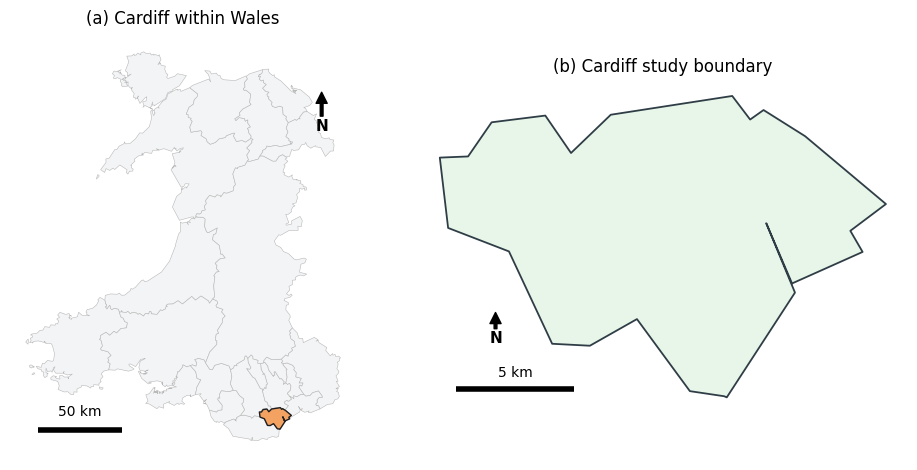

Saved figure to: /content/drive/MyDrive/GEOL0069_Data/figures/study_area_cardiff.png


In [11]:
# Plot Cardiff location and study boundary


import matplotlib.pyplot as plt
from pathlib import Path

# Make sure the figure folder exists
FIGURE_DIR = Path("/content/drive/MyDrive/GEOL0069_Data/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)



# Helper functions

def add_north_arrow(ax, x=0.90, y=0.86, size=0.08):
    """Add a simple north arrow using axis-relative coordinates."""
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - size),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=2,
            headwidth=8,
            headlength=8,
        ),
    )


def add_scale_bar(ax, length_km, location=(0.08, 0.07), linewidth=4):
    """
    Add a scale bar to a projected map.

    This assumes the map is plotted in a metre-based CRS such as EPSG:27700.
    """
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    x0 = x_min + location[0] * (x_max - x_min)
    y0 = y_min + location[1] * (y_max - y_min)

    length_m = length_km * 1000

    ax.plot(
        [x0, x0 + length_m],
        [y0, y0],
        color="black",
        linewidth=linewidth,
        solid_capstyle="butt",
    )

    ax.text(
        x0 + length_m / 2,
        y0 + 0.025 * (y_max - y_min),
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=10,
    )



# Reproject boundaries to British National Grid

wales_plot = district_gdf.to_crs("EPSG:27700")
cardiff_plot = cardiff_gdf.to_crs("EPSG:27700")



# Create figure

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))

# (a) Cardiff within Wales
wales_plot.plot(
    ax=axes[0],
    facecolor="#f3f4f6",
    edgecolor="#b8b8b8",
    linewidth=0.4,
)

cardiff_plot.plot(
    ax=axes[0],
    facecolor="#f4a261",
    edgecolor="#1f1f1f",
    linewidth=1.0,
)

axes[0].set_title("(a) Cardiff within Wales")
axes[0].set_axis_off()
add_north_arrow(axes[0], x=0.90, y=0.86)
add_scale_bar(axes[0], length_km=50, location=(0.08, 0.07))


# (b) Cardiff study boundary
cardiff_plot.plot(
    ax=axes[1],
    facecolor="#e8f5e9",
    edgecolor="#2f3e46",
    linewidth=1.3,
)

axes[1].set_title("(b) Cardiff study boundary")
axes[1].set_axis_off()
add_north_arrow(axes[1], x=0.16, y=0.30)
add_scale_bar(axes[1], length_km=5, location=(0.08, 0.07))



# Save and display

plt.tight_layout()

output_path = FIGURE_DIR / "study_area_cardiff.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure to: {output_path}")

In [12]:
def require_non_empty(name, arr):
    """
    Check that an array exists and contains at least one item.
    This prevents later model steps from running on empty data.
    """
    if arr is None:
        raise ValueError(f"{name} is None.")

    if len(arr) == 0:
        raise ValueError(f"{name} is empty. Check the AOI, date range, cloud mask, or label remapping.")

    print(f"{name}: {len(arr):,} samples")
t0 = time.perf_counter()

import json
import numpy as np
import pandas as pd
import ee
import geemap


# 1. Check required project variables


if "cardiff_gdf" not in globals():
    raise NameError("Run the Cardiff boundary cell first so cardiff_gdf is available.")

required_vars = [
    "START_DATE",
    "END_DATE",
    "SCALE",
    "RAW_BANDS",
    "FEATURE_NAMES",
    "CLASS_VALUES",
    "CLASS_NAMES",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError("Missing required variables: " + ", ".join(missing))



# 3. Convert Cardiff boundary to Earth Engine geometry


cardiff_gdf_wgs84 = cardiff_gdf.to_crs("EPSG:4326")
cardiff_geojson = json.loads(cardiff_gdf_wgs84.to_json())

aoi = geemap.geojson_to_ee(cardiff_geojson).geometry()



# 4. Fetch and cloud-mask Sentinel-2 imagery

# This uses Sentinel-2 Level-2A surface reflectance.
# The SCL band is used to remove obvious clouds, cloud shadows, cirrus,
# snow/ice, and invalid pixels.

s2_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 70))
)

scene_count = s2_collection.size().getInfo()
print(f"Sentinel-2 scenes after filtering: {scene_count}")

if scene_count == 0:
    raise ValueError(
        f"No Sentinel-2 scenes found for {START_DATE} to {END_DATE}. "
        "Try increasing the date range or cloud threshold."
    )


def mask_sentinel2_scl(image):
    scl = image.select("SCL")

    clear_mask = (
        scl.neq(0)    # no data
        .And(scl.neq(1))    # saturated / defective
        .And(scl.neq(3))    # cloud shadow
        .And(scl.neq(8))    # medium probability cloud
        .And(scl.neq(9))    # high probability cloud
        .And(scl.neq(10))   # cirrus
        .And(scl.neq(11))   # snow / ice
    )

    return (
        image
        .select(RAW_BANDS)
        .multiply(0.0001)
        .updateMask(clear_mask)
    )


s2_composite = (
    s2_collection
    .map(mask_sentinel2_scl)
    .median()
    .clip(aoi)
)



# 5. Add NDVI and NDBI

ndvi = s2_composite.normalizedDifference(["B8", "B4"]).rename("NDVI")
ndbi = s2_composite.normalizedDifference(["B11", "B8"]).rename("NDBI")

feature_image = (
    s2_composite
    .addBands([ndvi, ndbi])
    .select(FEATURE_NAMES)
    .toFloat()
    .clip(aoi)
)



# 6. Fetch and remap ESA WorldCover
# Original WorldCover classes are remapped into your Cardiff five-class scheme:
#
# 1 = Urban
# 2 = Tree and shrub
# 3 = Water
# 4 = Open land / Bare
# 5 = Grass and crop
#
# WorldCover mapping:
# 10 Tree cover          -> 2 Tree and shrub
# 20 Shrubland           -> 2 Tree and shrub
# 30 Grassland           -> 5 Grass and crop
# 40 Cropland            -> 5 Grass and crop
# 50 Built-up            -> 1 Urban
# 60 Bare/sparse veg     -> 4 Open land / Bare
# 80 Water               -> 3 Water
# 90 Herbaceous wetland  -> 5 Grass and crop
# 100 Moss/lichen        -> 5 Grass and crop

worldcover = (
    ee.ImageCollection("ESA/WorldCover/v100")
    .first()
    .select("Map")
    .clip(aoi)
)

label_image = (
    worldcover
    .remap(
        [10, 20, 30, 40, 50, 60, 80, 90, 100],
        [ 2,  2,  5,  5,  1,  4,  3,  5,   5],
        0
    )
    .rename("label")
    .toByte()
    .reproject(crs=feature_image.projection(), scale=SCALE)
    .clip(aoi)
)



# 7. Convert Earth Engine images to NumPy arrays

feature_arr = geemap.ee_to_numpy(
    feature_image,
    region=aoi,
    scale=SCALE
)

label_arr = geemap.ee_to_numpy(
    label_image,
    region=aoi,
    scale=SCALE
)

if feature_arr is None or label_arr is None:
    raise RuntimeError("Earth Engine returned empty arrays.")


# 8. Clean arrays and build model inputs

feature_arr = np.asarray(feature_arr, dtype="float32")
label_arr = np.squeeze(np.asarray(label_arr))

if feature_arr.ndim != 3:
    raise ValueError(f"feature_arr should be 3D, got {feature_arr.shape}")

if label_arr.ndim != 2:
    raise ValueError(f"label_arr should be 2D, got {label_arr.shape}")

if feature_arr.shape[:2] != label_arr.shape:
    raise ValueError(
        f"Feature and label grids do not match: "
        f"{feature_arr.shape[:2]} vs {label_arr.shape}"
    )

label_arr = np.where(np.isfinite(label_arr), label_arr, 0).astype("uint8")

valid_mask = np.isfinite(feature_arr).all(axis=2)
valid_mask &= np.nanmean(np.abs(feature_arr[:, :, :6]), axis=2) > 0

labelled_mask = valid_mask & np.isin(label_arr, CLASS_VALUES)

X_all = feature_arr[valid_mask]
X_labelled = feature_arr[labelled_mask]
y_labelled = label_arr[labelled_mask].astype("uint8")

labelled_rows, labelled_cols = np.where(labelled_mask)

require_non_empty("Valid Sentinel-2 feature pixels", X_all)
require_non_empty("WorldCover-labelled pixels", X_labelled)



# 9. Print summary

if "timing" not in globals():
    timing = {}

timing["preprocessing"] = time.perf_counter() - t0

label_counts = (
    pd.Series(y_labelled)
    .map(CLASS_NAMES)
    .value_counts()
    .reindex(CLASS_NAMES.values(), fill_value=0)
)

print("Pre-processing summary")
print("=" * 50)
print("Data source: Google Earth Engine")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Scale: {SCALE} m")
print(f"Feature array shape: {feature_arr.shape}")
print(f"Label array shape: {label_arr.shape}")
print(f"Valid pixel count: {X_all.shape[0]:,}")
print(f"Labelled pixel count: {X_labelled.shape[0]:,}")
print(f"Runtime: {timing['preprocessing']:.1f} seconds")

print("\nLabelled pixel count by class")
for class_name, count in label_counts.items():
    print(f"- {class_name}: {count:,}")

Sentinel-2 scenes after filtering: 23
Valid Sentinel-2 feature pixels: 572,941 samples
WorldCover-labelled pixels: 424,758 samples
Pre-processing summary
Data source: Google Earth Engine
Date range: 2021-04-01 to 2021-06-30
Scale: 20 m
Feature array shape: (640, 1519, 8)
Label array shape: (640, 1519)
Valid pixel count: 572,941
Labelled pixel count: 424,758
Runtime: 10.7 seconds

Labelled pixel count by class
- Urban: 153,416
- Tree and shrub: 142,619
- Water: 12,406
- Open land / Bare: 4,965
- Grass and crop: 111,352


Effective pixels after cleaning: 572,941


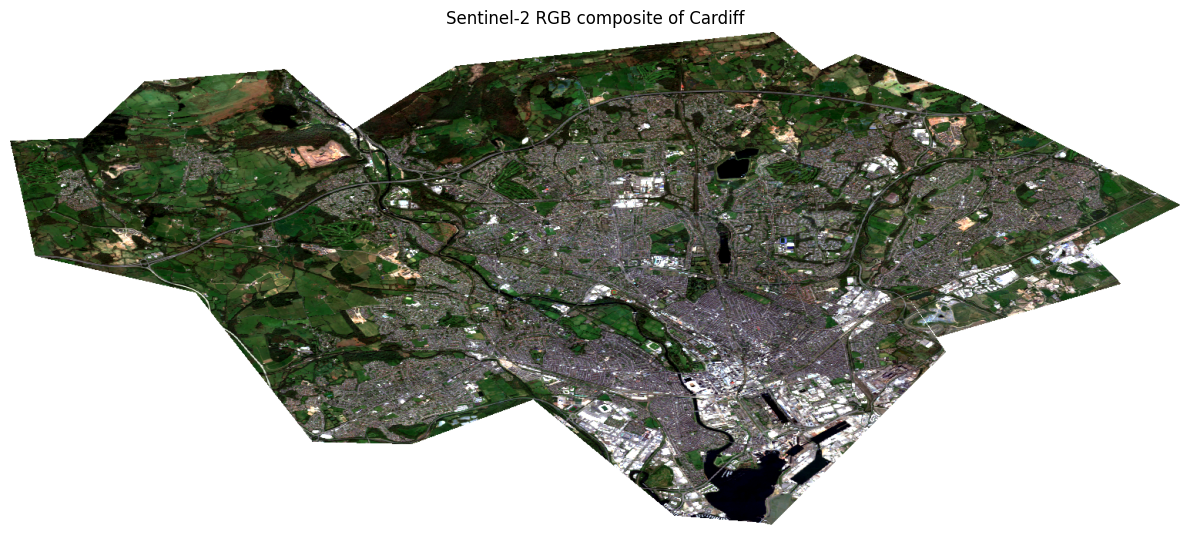

Saved RGB figure to: /content/drive/MyDrive/GEOL0069_Data/figures/cardiff_sentinel2_rgb.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt

FIGURE_DIR.mkdir(parents=True, exist_ok=True)


feature_arr_clean = np.where(np.isfinite(feature_arr), feature_arr, np.nan)
valid_rgb_mask = np.isfinite(feature_arr_clean).all(axis=2)

print(f"Effective pixels after cleaning: {valid_rgb_mask.sum():,}")

rgb = feature_arr_clean[:, :, [2, 1, 0]].copy()
rgb[~valid_rgb_mask] = np.nan


rgb_display = np.zeros_like(rgb, dtype="float32")

for i in range(3):
    band = rgb[:, :, i]
    valid_values = band[np.isfinite(band)]

    if valid_values.size == 0:
        continue

    lower, upper = np.percentile(valid_values, [2, 98])

    if upper > lower:
        rgb_display[:, :, i] = np.clip((band - lower) / (upper - lower), 0, 1)

rgb_display[~np.isfinite(rgb_display)] = 1


if "extent" in globals() and len(extent) == 4:
    extent_plot = [extent[0], extent[2], extent[1], extent[3]]
else:
    extent_plot = None


fig, ax = plt.subplots(figsize=(12, 9))

if extent_plot is not None:
    ax.imshow(rgb_display, extent=extent_plot, origin="upper")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    ax.imshow(rgb_display, origin="upper")
    ax.set_axis_off()

ax.set_title("Sentinel-2 RGB composite of Cardiff")
ax.grid(False)

plt.tight_layout()

rgb_output_path = FIGURE_DIR / "cardiff_sentinel2_rgb.png"

fig.savefig(
    rgb_output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved RGB figure to: {rgb_output_path}")






# Method Overview

This project compares two machine-learning approaches for five-class land-cover classification in Cardiff using Sentinel-2 imagery from Google Earth Engine. The same Sentinel-2 feature stack is used for both methods, containing six spectral bands and two derived indices: NDVI and NDBI. This ensures that differences in the outputs mainly reflect the modelling approach rather than differences in input data.

The five target classes are **Urban**, **Tree and shrub**, **Water**, **Open land / Bare**, and **Grass and crop**. These classes are selected because Cardiff contains a mixture of built-up surfaces, Cardiff Bay, the River Taff, parks, woodland, grassland, cropland, and exposed surfaces.

The project uses **K-means clustering** as a supervised baseline and **Gradient Boosting** as an unsupervised classifier. K-means tests whether pixels naturally group into meaningful spectral clusters without reference labels. Gradient Boosting uses WorldCover-derived labels to learn relationships between Sentinel-2 features and land-cover classes. Comparing the two methods helps answer the research question by assessing how well Sentinel-2 bands and indices distinguish Cardiff’s main land-cover types.

## K-means Workflow

K-means is used as the supervised classification method. It groups pixels according to similarity in the Sentinel-2 feature space without using the WorldCover labels during training. This makes it useful as a baseline for testing whether Cardiff’s land-cover classes are naturally separable from spectral information alone.

Before clustering, valid Sentinel-2 pixels are extracted from the feature array and standardised so that all bands and indices contribute more equally to the distance calculation. A random sample of up to 50,000 valid pixels is used to keep the clustering computationally manageable in Google Colab while still representing the study area.

Because the project uses five target land-cover classes, the final K-means model uses **k = 5**. Elbow and silhouette diagnostics are reported to check cluster behaviour, but the final k value is selected to match the five-class comparison framework. After clustering, the resulting cluster IDs are interpreted using NDVI, NDBI, spectral profiles, and visual map inspection, then translated into the five Cardiff land-cover classes.

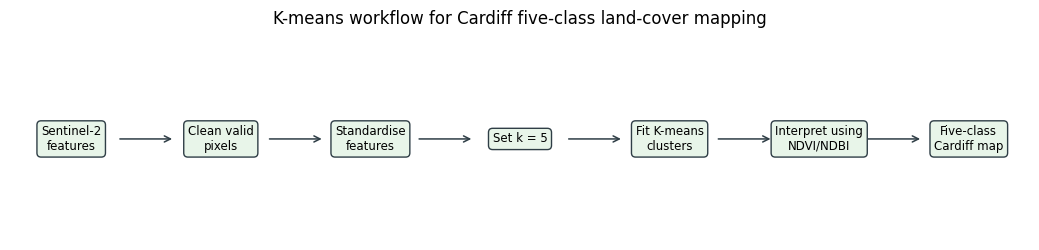

Saved K-means workflow figure to: /content/drive/MyDrive/GEOL0069_Data/figures/kmeans_workflow_cardiff.png


In [14]:
# K-means workflow diagram for Cardiff project

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(10.5, 2.6))
ax.axis("off")

steps = [
    "Sentinel-2\nfeatures",
    "Clean valid\npixels",
    "Standardise\nfeatures",
    "Set k = 5",
    "Fit K-means\nclusters",
    "Interpret using\nNDVI/NDBI",
    "Five-class\nCardiff map",
]

x_positions = np.linspace(0.06, 0.94, len(steps))

for i, (x, label) in enumerate(zip(x_positions, steps)):
    ax.text(
        x,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#e8f5e9",
            edgecolor="#2f3e46",
            linewidth=1.0,
        ),
    )

    if i < len(steps) - 1:
        ax.add_patch(
            FancyArrowPatch(
                (x + 0.045, 0.5),
                (x_positions[i + 1] - 0.045, 0.5),
                arrowstyle="->",
                mutation_scale=11,
                linewidth=1.1,
                color="#2f3e46",
            )
        )

ax.set_title(
    "K-means workflow for Cardiff five-class land-cover mapping",
    fontsize=12,
    pad=10,
)

plt.tight_layout()

output_path = FIGURE_DIR / "kmeans_workflow_cardiff.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved K-means workflow figure to: {output_path}")


Valid Sentinel-2 feature pixels: 572,941 samples
K-means clustering
Valid Sentinel-2 pixels: 572,941
Number of features: 8
K-means training sample: 50,000 pixels (8.7% of valid pixels)


,k,inertia,silhouette
0,3,187192.422,0.397
1,4,152488.188,0.351
2,5,123882.703,0.357
3,6,104348.695,0.350
4,7,92108.055,0.322


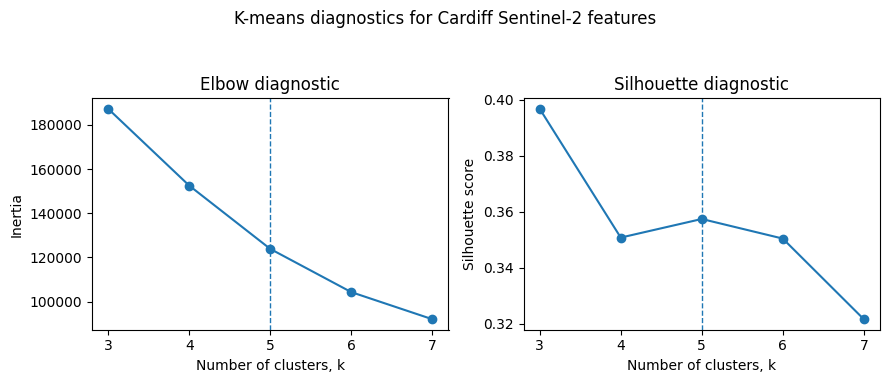

Saved K-means diagnostics to: /content/drive/MyDrive/GEOL0069_Data/figures/kmeans_diagnostics_cardiff.png
Final K-means model fitted with k = 5


,cluster_id,pixel_count,pixel_percent
0,0,22705,3.96
1,1,213881,37.33
2,2,157209,27.44
3,3,165184,28.83
4,4,13962,2.44


K-means runtime: 17.7 seconds
K-means cluster map created successfully.


In [15]:
# K-means clustering: five-class baseline

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

t0 = time.perf_counter()


# 1. Check input data


require_non_empty("Valid Sentinel-2 feature pixels", X_all)

print("K-means clustering")
print("=" * 50)
print(f"Valid Sentinel-2 pixels: {X_all.shape[0]:,}")
print(f"Number of features: {X_all.shape[1]}")



# 2. Sample valid pixels for K-means training
# K-means is fitted on a random sample to keep runtime manageable.

KMEANS_SAMPLE_SIZE = min(50_000, X_all.shape[0])

sample_indices = rng.choice(
    X_all.shape[0],
    size=KMEANS_SAMPLE_SIZE,
    replace=False
)

X_kmeans_sample = X_all[sample_indices]

print(
    f"K-means training sample: {KMEANS_SAMPLE_SIZE:,} pixels "
    f"({100 * KMEANS_SAMPLE_SIZE / X_all.shape[0]:.1f}% of valid pixels)"
)



# 3. Standardise features
# K-means uses distance, so scaling is required.

scaler_kmeans = StandardScaler()
X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans_sample)


# 4. Test candidate k values
# The final project uses k = 5, but diagnostics are reported for comparison.

candidate_k = [3, 4, 5, 6, 7]
k_metrics = []

silhouette_n = min(10_000, X_kmeans_scaled.shape[0])
silhouette_indices = rng.choice(
    X_kmeans_scaled.shape[0],
    size=silhouette_n,
    replace=False
)

X_silhouette = X_kmeans_scaled[silhouette_indices]

for k in candidate_k:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = km.fit_predict(X_kmeans_scaled)
    sil = silhouette_score(
        X_silhouette,
        labels[silhouette_indices]
    )

    k_metrics.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": sil,
    })

k_metrics_df = pd.DataFrame(k_metrics)
display(k_metrics_df.round(3))



# 5. Plot K-means diagnostics

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

axes[0].plot(k_metrics_df["k"], k_metrics_df["inertia"], marker="o")
axes[0].axvline(5, linestyle="--", linewidth=1)
axes[0].set_title("Elbow diagnostic")
axes[0].set_xlabel("Number of clusters, k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_metrics_df["k"], k_metrics_df["silhouette"], marker="o")
axes[1].axvline(5, linestyle="--", linewidth=1)
axes[1].set_title("Silhouette diagnostic")
axes[1].set_xlabel("Number of clusters, k")
axes[1].set_ylabel("Silhouette score")

plt.suptitle("K-means diagnostics for Cardiff Sentinel-2 features", y=1.05)
plt.tight_layout()

diagnostic_path = FIGURE_DIR / "kmeans_diagnostics_cardiff.png"
fig.savefig(diagnostic_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved K-means diagnostics to: {diagnostic_path}")


# 6. Fit final K-means model with k = 5
# k = 5 matches the five target land-cover classes:
# Urban, Tree/shrub, Water, Open/Bare, Grass/crop.

selected_k = 5

kmeans = KMeans(
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=20
)

kmeans.fit(X_kmeans_scaled)

print(f"Final K-means model fitted with k = {selected_k}")



# 7. Predict clusters for all valid pixels

X_all_scaled = scaler_kmeans.transform(X_all)
cluster_pred = kmeans.predict(X_all_scaled)

cluster_map = np.full(valid_mask.shape, -1, dtype="int16")
cluster_map[valid_mask] = cluster_pred


# 8. Summarise cluster sizes

cluster_ids, cluster_counts = np.unique(cluster_pred, return_counts=True)

cluster_summary = pd.DataFrame({
    "cluster_id": cluster_ids,
    "pixel_count": cluster_counts,
})

cluster_summary["pixel_percent"] = (
    100 * cluster_summary["pixel_count"] / cluster_summary["pixel_count"].sum()
)

display(cluster_summary.round(2))



# 9. Save runtime

if "timing" not in globals():
    timing = {}

timing["kmeans"] = time.perf_counter() - t0

print("=" * 50)
print(f"K-means runtime: {timing['kmeans']:.1f} seconds")
print("K-means cluster map created successfully.")

Feature names: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDBI']


,cluster,B2,B3,B4,B8,B11,B12,NDVI,NDBI,pixel_count,pixel_percent,visible_brightness,swir_mean
0,0,0.1716,0.1941,0.2135,0.2623,0.2667,0.2358,0.1070,0.0091,22705,3.9629,0.1931,0.2512
1,1,0.0729,0.0889,0.0953,0.1869,0.1856,0.1483,0.3132,0.0050,213881,37.3304,0.0857,0.1670
2,2,0.0420,0.0752,0.0582,0.4137,0.2302,0.1267,0.7482,-0.2815,157209,27.4390,0.0585,0.1784
3,3,0.0358,0.0572,0.0481,0.2594,0.1703,0.1033,0.6811,-0.2015,165184,28.8309,0.0470,0.1368
4,4,0.0330,0.0393,0.0311,0.0305,0.0326,0.0241,-0.0756,-0.0338,13962,2.4369,0.0345,0.0284


K-means cluster interpretation:
Cluster 0 -> Urban
Cluster 1 -> Open land / Bare
Cluster 2 -> Tree and shrub
Cluster 3 -> Grass and crop
Cluster 4 -> Water
Unique values in K-means class map: [0 1 2 3 4 5]


,class_id,class_name,pixel_count,pixel_percent,area_km2
0,1,Urban,22705,3.963,9.082
1,2,Tree and shrub,157209,27.439,62.884
2,3,Water,13962,2.437,5.585
3,4,Open land / Bare,213881,37.330,85.552
4,5,Grass and crop,165184,28.831,66.074


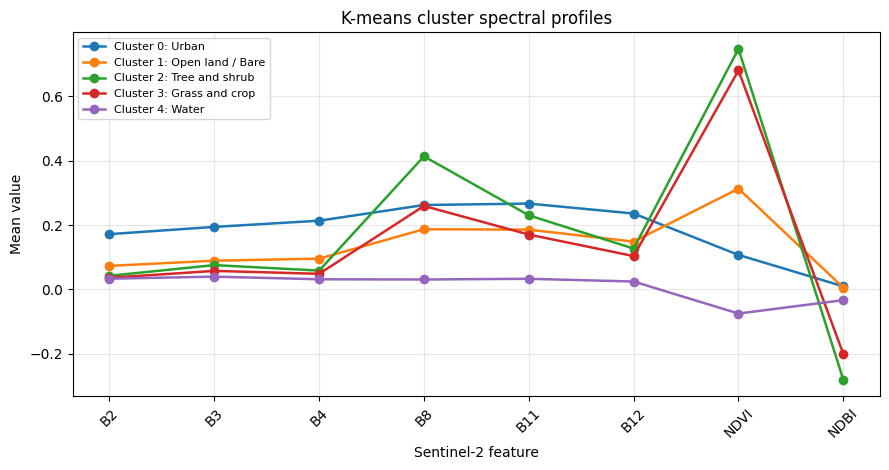

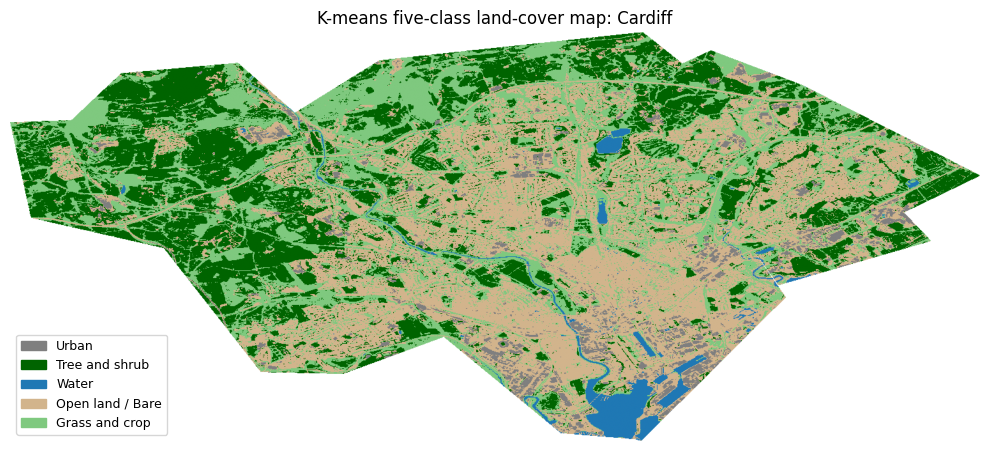

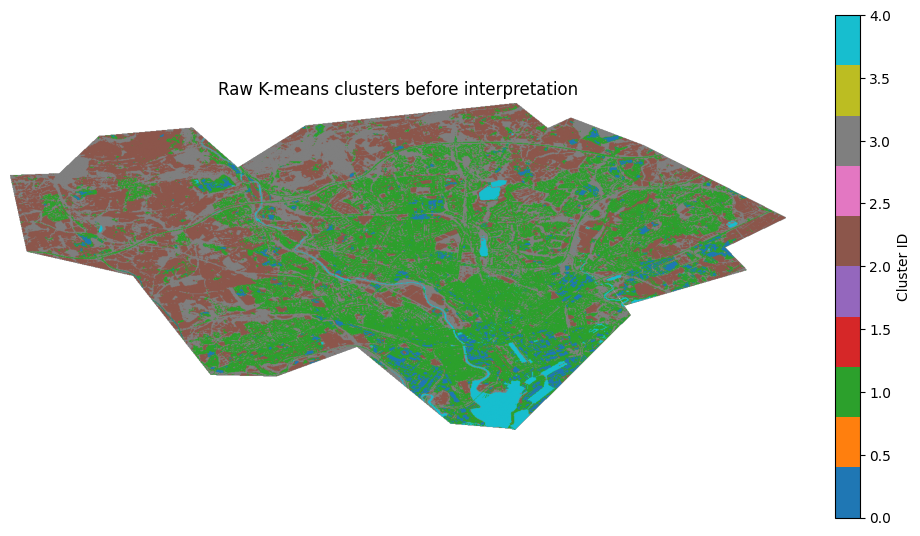

K-means interpretation runtime: 7.2 seconds
Saved outputs:
- /content/drive/MyDrive/GEOL0069_Data/figures/kmeans_cluster_profiles_cardiff.png
- /content/drive/MyDrive/GEOL0069_Data/figures/kmeans_five_class_map_cardiff.png
- /content/drive/MyDrive/GEOL0069_Data/figures/kmeans_raw_clusters_cardiff.png


In [16]:
# K-means cluster interpretation and five-class Cardiff map

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

t0 = time.perf_counter()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Feature names and class settings

feature_names = FEATURE_NAMES

class_names = {
    1: "Urban",
    2: "Tree and shrub",
    3: "Water",
    4: "Open land / Bare",
    5: "Grass and crop",
}

class_colors = {
    0: "#ffffff",
    1: "#7f7f7f",
    2: "#006400",
    3: "#1f78b4",
    4: "#d2b48c",
    5: "#7fc97f",
}

print("Feature names:", feature_names)


# 2. Calculate cluster spectral profiles

kmeans_df = pd.DataFrame(X_all, columns=feature_names)
kmeans_df["cluster"] = cluster_pred

cluster_profiles = (
    kmeans_df
    .groupby("cluster")[feature_names]
    .mean()
    .reset_index()
)

cluster_counts = (
    kmeans_df["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="pixel_count")
)

cluster_profiles = cluster_profiles.merge(cluster_counts, on="cluster")
cluster_profiles["pixel_percent"] = (
    100 * cluster_profiles["pixel_count"] / cluster_profiles["pixel_count"].sum()
)

# Use feature names from the notebook: B2, B3, B4, B8, B11, B12, NDVI, NDBI
cluster_profiles["visible_brightness"] = (
    cluster_profiles["B2"] + cluster_profiles["B3"] + cluster_profiles["B4"]
) / 3

cluster_profiles["swir_mean"] = (
    cluster_profiles["B11"] + cluster_profiles["B12"]
) / 2

display(cluster_profiles.round(4))



# 3. Automatically assign clusters to five classes
# These are first-pass rules based on typical Sentinel-2 behaviour:
# Water = lowest NDVI
# Tree/shrub = highest NDVI
# Urban = highest NDBI
# Open/bare = bright and high SWIR, low NDVI
# Grass/crop = remaining cluster

remaining = set(cluster_profiles["cluster"])
cluster_to_class = {}

water_cluster = cluster_profiles.loc[cluster_profiles["NDVI"].idxmin(), "cluster"]
cluster_to_class[int(water_cluster)] = 3
remaining.remove(water_cluster)

tree_cluster = cluster_profiles[cluster_profiles["cluster"].isin(remaining)].loc[
    cluster_profiles[cluster_profiles["cluster"].isin(remaining)]["NDVI"].idxmax(),
    "cluster",
]
cluster_to_class[int(tree_cluster)] = 2
remaining.remove(tree_cluster)

urban_cluster = cluster_profiles[cluster_profiles["cluster"].isin(remaining)].loc[
    cluster_profiles[cluster_profiles["cluster"].isin(remaining)]["NDBI"].idxmax(),
    "cluster",
]
cluster_to_class[int(urban_cluster)] = 1
remaining.remove(urban_cluster)

remaining_df = cluster_profiles[cluster_profiles["cluster"].isin(remaining)].copy()
remaining_df["bare_score"] = (
    remaining_df["visible_brightness"].rank(pct=True)
    + remaining_df["swir_mean"].rank(pct=True)
    - remaining_df["NDVI"].rank(pct=True)
)

bare_cluster = remaining_df.loc[remaining_df["bare_score"].idxmax(), "cluster"]
cluster_to_class[int(bare_cluster)] = 4
remaining.remove(bare_cluster)

grass_cluster = list(remaining)[0]
cluster_to_class[int(grass_cluster)] = 5

print("K-means cluster interpretation:")
for cluster_id, class_id in sorted(cluster_to_class.items()):
    print(f"Cluster {cluster_id} -> {class_names[class_id]}")


# 4. Convert raw clusters to interpreted five-class map

kmeans_class_map = np.zeros(cluster_map.shape, dtype="uint8")

for cluster_id, class_id in cluster_to_class.items():
    kmeans_class_map[cluster_map == cluster_id] = class_id

print("Unique values in K-means class map:", np.unique(kmeans_class_map))


# 5. K-means area summary

valid_classes = kmeans_class_map[kmeans_class_map > 0]
class_ids, class_counts = np.unique(valid_classes, return_counts=True)

kmeans_area_summary = pd.DataFrame({
    "class_id": class_ids,
    "class_name": [class_names[int(i)] for i in class_ids],
    "pixel_count": class_counts,
})

kmeans_area_summary["pixel_percent"] = (
    100 * kmeans_area_summary["pixel_count"] / kmeans_area_summary["pixel_count"].sum()
)

pixel_area_km2 = (SCALE * SCALE) / 1_000_000
kmeans_area_summary["area_km2"] = kmeans_area_summary["pixel_count"] * pixel_area_km2

display(kmeans_area_summary.round(3))



# 6. Plot cluster spectral profiles

fig, ax = plt.subplots(figsize=(9, 4.8))

for _, row in cluster_profiles.iterrows():
    cluster_id = int(row["cluster"])
    class_id = cluster_to_class[cluster_id]

    ax.plot(
        feature_names,
        row[feature_names],
        marker="o",
        linewidth=1.8,
        label=f"Cluster {cluster_id}: {class_names[class_id]}",
    )

ax.set_title("K-means cluster spectral profiles")
ax.set_xlabel("Sentinel-2 feature")
ax.set_ylabel("Mean value")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "kmeans_cluster_profiles_cardiff.png", dpi=300, bbox_inches="tight")
plt.show()


# 7. Plot interpreted five-class K-means map

cmap = ListedColormap([class_colors[i] for i in range(6)])
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

legend_patches = [
    mpatches.Patch(color=class_colors[i], label=class_names[i])
    for i in class_names
]

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(kmeans_class_map, cmap=cmap, norm=norm)
ax.set_title("K-means five-class land-cover map: Cardiff")
ax.set_axis_off()
ax.legend(handles=legend_patches, loc="lower left", frameon=True, fontsize=9)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "kmeans_five_class_map_cardiff.png", dpi=300, bbox_inches="tight")
plt.show()


# 8. Plot raw K-means clusters

fig, ax = plt.subplots(figsize=(10, 7))

raw_cluster_map = np.where(cluster_map >= 0, cluster_map, np.nan)
im = ax.imshow(raw_cluster_map, cmap="tab10")

ax.set_title("Raw K-means clusters before interpretation")
ax.set_axis_off()

cbar = plt.colorbar(im, ax=ax, shrink=0.75)
cbar.set_label("Cluster ID")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "kmeans_raw_clusters_cardiff.png", dpi=300, bbox_inches="tight")
plt.show()


# 9. Run time

if "timing" not in globals():
    timing = {}

timing["kmeans_interpretation"] = time.perf_counter() - t0

print("=" * 50)
print(f"K-means interpretation runtime: {timing['kmeans_interpretation']:.1f} seconds")
print("Saved outputs:")
print(f"- {FIGURE_DIR / 'kmeans_cluster_profiles_cardiff.png'}")
print(f"- {FIGURE_DIR / 'kmeans_five_class_map_cardiff.png'}")
print(f"- {FIGURE_DIR / 'kmeans_raw_clusters_cardiff.png'}")

## Gradient boosting workflow

Unlike K-means, it uses the WorldCover-derived five-class labels during training. The model learns relationships between the Sentinel-2 feature stack and the target land-cover classes: Urban, Tree and shrub, Water, Open land / Bare, and Grass and crop.

The labelled pixels are split into training and testing sets so that model performance can be evaluated on data not used for fitting. The classifier is trained using the Sentinel-2 bands and indices, including NDVI and NDBI. Gradient Boosting builds trees sequentially, where each new tree attempts to correct errors made by previous trees. This makes it suitable for modelling non-linear class boundaries between spectrally similar urban and vegetated surfaces.

After training, the model predicts labels for the test pixels and is evaluated using accuracy, Cohen’s kappa, a classification report, and a confusion matrix. The trained model is then applied to all valid Sentinel-2 pixels to produce a full five-class land-cover map for Cardiff.



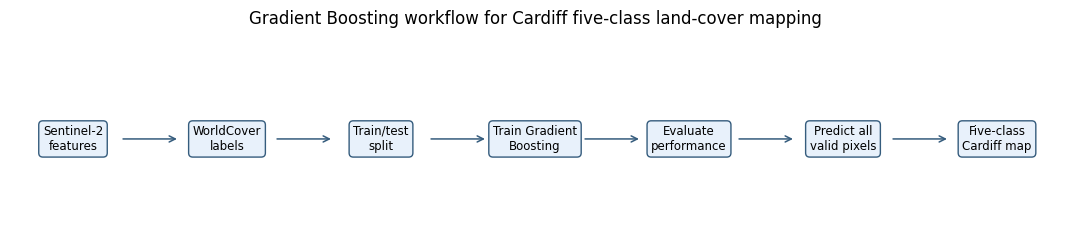

Saved Gradient Boosting workflow figure to: /content/drive/MyDrive/GEOL0069_Data/figures/gradient_boosting_workflow_cardiff.png
Gradient Boosting workflow cell runtime: 1.17 seconds


In [17]:
# Gradient Boosting workflow diagram

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

t0 = time.perf_counter()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10.8, 2.6))
ax.axis("off")

steps = [
    "Sentinel-2\nfeatures",
    "WorldCover\nlabels",
    "Train/test\nsplit",
    "Train Gradient\nBoosting",
    "Evaluate\nperformance",
    "Predict all\nvalid pixels",
    "Five-class\nCardiff map",
]

x_positions = np.linspace(0.06, 0.94, len(steps))

for i, (x, label) in enumerate(zip(x_positions, steps)):
    ax.text(
        x,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#e8f1fb",
            edgecolor="#355c7d",
            linewidth=1.0,
        ),
    )

    if i < len(steps) - 1:
        ax.add_patch(
            FancyArrowPatch(
                (x + 0.045, 0.5),
                (x_positions[i + 1] - 0.045, 0.5),
                arrowstyle="->",
                mutation_scale=11,
                linewidth=1.1,
                color="#355c7d",
            )
        )

ax.set_title(
    "Gradient Boosting workflow for Cardiff five-class land-cover mapping",
    fontsize=12,
    pad=10,
)

plt.tight_layout()

gb_workflow_path = FIGURE_DIR / "gradient_boosting_workflow_cardiff.png"
fig.savefig(gb_workflow_path, dpi=300, bbox_inches="tight")
plt.show()

if "timing" not in globals():
    timing = {}

timing["gb_workflow_diagram"] = time.perf_counter() - t0

print(f"Saved Gradient Boosting workflow figure to: {gb_workflow_path}")
print(f"Gradient Boosting workflow cell runtime: {timing['gb_workflow_diagram']:.2f} seconds")

Labelled Sentinel-2 pixels: 424,758 samples
Gradient Boosting training and evaluation
Labelled pixels: 424,758
Number of features: 8
Features: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDBI']

Sampling summary


,class_id,class_name,available_pixels,sampled_pixels
0,1,Urban,153416,4000
1,2,Tree and shrub,142619,4000
2,3,Water,12406,4000
3,4,Open land / Bare,4965,4000
4,5,Grass and crop,111352,4000



Training pixels: 14,000
Testing pixels: 6,000

Boosting iterations used: 71

Gradient Boosting evaluation
Overall agreement with WorldCover-derived labels: 0.312
Cohen's kappa: 0.141


,precision,recall,f1-score,support
Urban,0.254,0.312,0.280,1200.000
Tree and shrub,0.265,0.283,0.274,1200.000
Water,0.409,0.512,0.455,1200.000
Open land / Bare,0.287,0.226,0.253,1200.000
Grass and crop,0.344,0.230,0.276,1200.000
accuracy,0.312,0.312,0.312,0.312
macro avg,0.312,0.312,0.307,6000.000
weighted avg,0.312,0.312,0.307,6000.000



Confusion matrix


,Pred: Urban,Pred: Tree and shrub,Pred: Water,Pred: Open land / Bare,Pred: Grass and crop
True: Urban,374,310,185,215,116
True: Tree and shrub,355,340,184,165,156
True: Water,200,138,614,136,112
True: Open land / Bare,291,225,271,271,142
True: Grass and crop,251,269,246,158,276


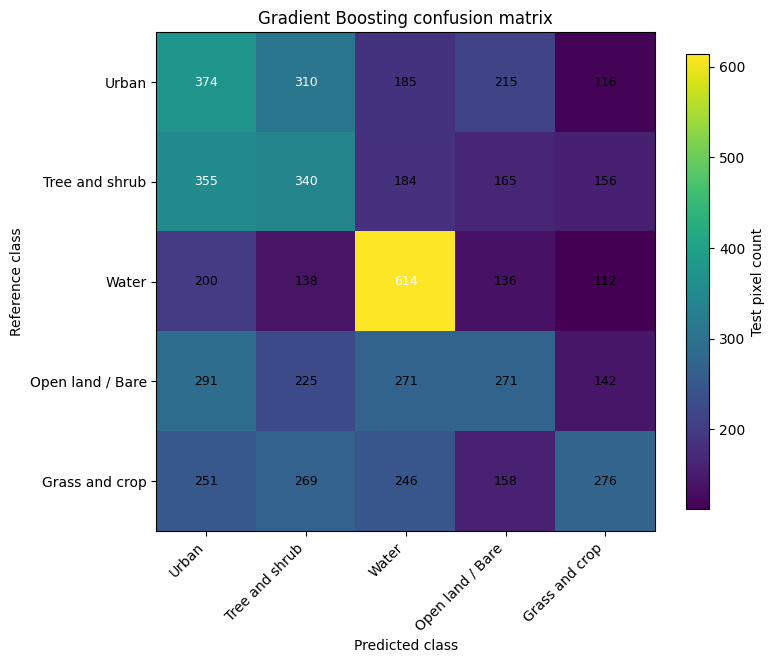


Metric summary


,model,overall_accuracy,cohen_kappa,train_pixels,test_pixels,boosting_iterations
0,Gradient Boosting,0.312,0.141,14000,6000,71


Gradient Boosting training/evaluation runtime: 3.1 seconds
Saved confusion matrix figure to: /content/drive/MyDrive/GEOL0069_Data/figures/gradient_boosting_confusion_matrix_cardiff.png


In [18]:
# Gradient Boosting: training and evaluation

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
)

t0 = time.perf_counter()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Check required inputs

required_vars = [
    "X_labelled",
    "y_labelled",
    "X_all",
    "valid_mask",
    "CLASS_VALUES",
    "CLASS_NAMES",
    "FEATURE_NAMES",
    "RANDOM_STATE",
    "rng",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError("Missing required variables: " + ", ".join(missing))

require_non_empty("Labelled Sentinel-2 pixels", X_labelled)

print("Gradient Boosting training and evaluation")
print("=" * 55)
print(f"Labelled pixels: {X_labelled.shape[0]:,}")
print(f"Number of features: {X_labelled.shape[1]}")
print(f"Features: {FEATURE_NAMES}")


# 2. Balanced sampling by class
# This reduces dominance by common classes such as Urban or Grass/crop.

GB_SAMPLE_CAP_PER_CLASS = 4000

sampled_indices = []
sampling_rows = []

for class_id in CLASS_VALUES:
    class_indices = np.flatnonzero(y_labelled == class_id)
    n_available = len(class_indices)

    if n_available == 0:
        raise ValueError(
            f"No labelled pixels found for class {class_id}: {CLASS_NAMES[class_id]}"
        )

    n_sample = min(GB_SAMPLE_CAP_PER_CLASS, n_available)
    chosen = rng.choice(class_indices, size=n_sample, replace=False)

    sampled_indices.append(chosen)
    sampling_rows.append({
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id],
        "available_pixels": n_available,
        "sampled_pixels": n_sample,
    })

sampled_indices = np.concatenate(sampled_indices)
rng.shuffle(sampled_indices)

X_gb = X_labelled[sampled_indices]
y_gb = y_labelled[sampled_indices]

gb_sampling_df = pd.DataFrame(sampling_rows)

print("\nSampling summary")
display(gb_sampling_df)


# 3. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X_gb,
    y_gb,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_gb,
)

print(f"\nTraining pixels: {X_train.shape[0]:,}")
print(f"Testing pixels: {X_test.shape[0]:,}")


# 4. Train Gradient Boosting model
# Histogram Gradient Boosting is efficient for tabular Sentinel-2 features.

gb_model = HistGradientBoostingClassifier(
    max_iter=250,
    learning_rate=0.06,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=0.05,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)

gb_model.fit(X_train, y_train)

print(f"\nBoosting iterations used: {gb_model.n_iter_}")


# 5. Test-set prediction and evaluation

gb_test_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_test_pred)
gb_kappa = cohen_kappa_score(y_test, gb_test_pred)

print("\nGradient Boosting evaluation")
print("=" * 55)
print(f"Overall agreement with WorldCover-derived labels: {gb_accuracy:.3f}")
print(f"Cohen's kappa: {gb_kappa:.3f}")

gb_report_df = pd.DataFrame(
    classification_report(
        y_test,
        gb_test_pred,
        labels=CLASS_VALUES,
        target_names=[CLASS_NAMES[i] for i in CLASS_VALUES],
        output_dict=True,
        zero_division=0,
    )
).T

display(gb_report_df.round(3))


# 6. Confusion matrix

gb_cm = confusion_matrix(
    y_test,
    gb_test_pred,
    labels=CLASS_VALUES
)

gb_cm_df = pd.DataFrame(
    gb_cm,
    index=[f"True: {CLASS_NAMES[i]}" for i in CLASS_VALUES],
    columns=[f"Pred: {CLASS_NAMES[i]}" for i in CLASS_VALUES],
)

print("\nConfusion matrix")
display(gb_cm_df)


# 7. Plot and save confusion matrix figure

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(gb_cm)

tick_labels = [CLASS_NAMES[i] for i in CLASS_VALUES]

ax.set_title("Gradient Boosting confusion matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Reference class")
ax.set_xticks(np.arange(len(CLASS_VALUES)))
ax.set_yticks(np.arange(len(CLASS_VALUES)))
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_yticklabels(tick_labels)

threshold = gb_cm.max() / 2 if gb_cm.max() > 0 else 0

for i in range(gb_cm.shape[0]):
    for j in range(gb_cm.shape[1]):
        value = gb_cm[i, j]
        ax.text(
            j,
            i,
            f"{value}",
            ha="center",
            va="center",
            color="white" if value > threshold else "black",
            fontsize=9,
        )

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Test pixel count")

plt.tight_layout()

gb_cm_path = FIGURE_DIR / "gradient_boosting_confusion_matrix_cardiff.png"
fig.savefig(gb_cm_path, dpi=300, bbox_inches="tight")
plt.show()



# 8. Metric summary and runtime

gb_metrics = pd.DataFrame([{
    "model": "Gradient Boosting",
    "overall_accuracy": gb_accuracy,
    "cohen_kappa": gb_kappa,
    "train_pixels": len(y_train),
    "test_pixels": len(y_test),
    "boosting_iterations": gb_model.n_iter_,
}])

print("\nMetric summary")
display(gb_metrics.round(3))

if "timing" not in globals():
    timing = {}

timing["gradient_boosting_training_evaluation"] = time.perf_counter() - t0

print("=" * 55)
print(
    "Gradient Boosting training/evaluation runtime: "
    f"{timing['gradient_boosting_training_evaluation']:.1f} seconds"
)
print(f"Saved confusion matrix figure to: {gb_cm_path}")

Gradient Boosting prediction and mapping
Raw Gradient Boosting prediction summary
Mean confidence: 0.334
Minimum confidence: 0.203
Maximum confidence: 0.944
Raw Water pixels: 129,886
Implausible Water pixels corrected: 129,863
Corrected Water pixels: 23
Final Gradient Boosting map classes: [0 1 2 3 4 5]

Gradient Boosting area summary


,class_id,class_name,pixel_count,pixel_percent,area_km2
0,1,Urban,165644,28.911,66.258
1,2,Tree and shrub,129889,22.671,51.956
2,3,Water,23,0.004,0.009
3,4,Open land / Bare,142524,24.876,57.010
4,5,Grass and crop,134861,23.538,53.944


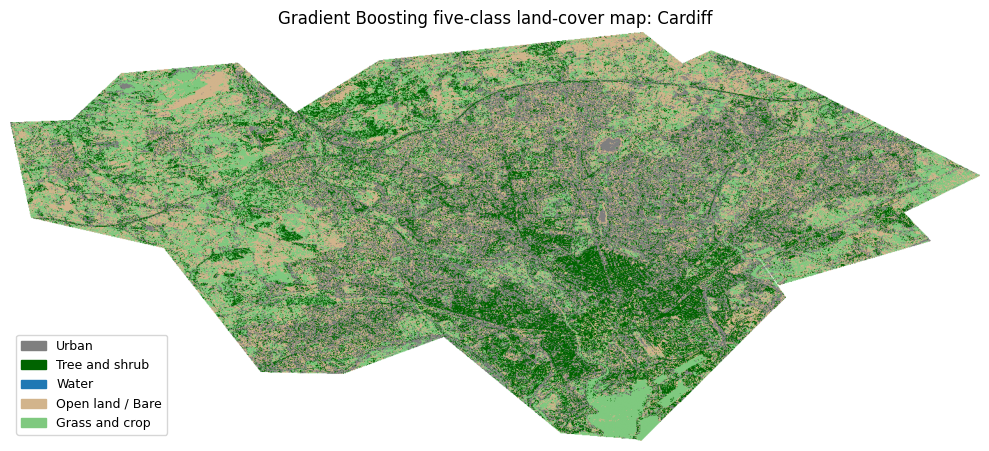

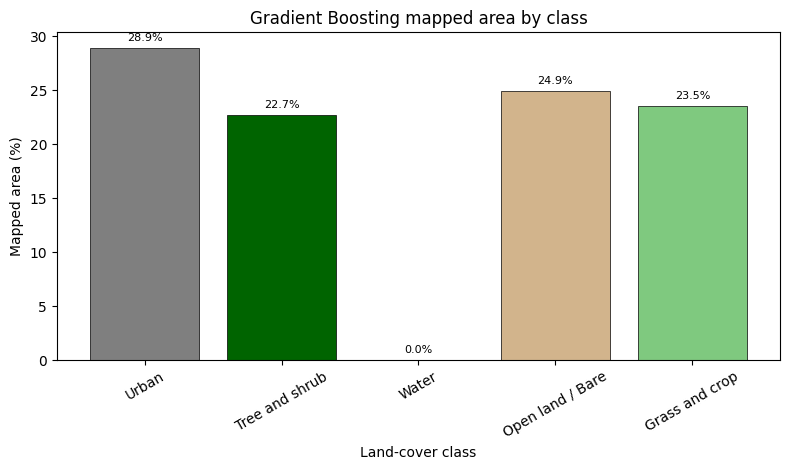

Gradient Boosting prediction/mapping runtime: 49.9 seconds
Saved map: /content/drive/MyDrive/GEOL0069_Data/figures/gradient_boosting_five_class_map_cardiff.png
Saved area chart: /content/drive/MyDrive/GEOL0069_Data/figures/gradient_boosting_area_chart_cardiff.png


In [19]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

t0 = time.perf_counter()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Check required inputs

required_vars = [
    "gb_model",
    "X_all",
    "valid_mask",
    "FEATURE_NAMES",
    "CLASS_VALUES",
    "CLASS_NAMES",
    "SCALE",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError("Missing required variables: " + ", ".join(missing))

print("Gradient Boosting prediction and mapping")
print("=" * 60)


# 2. Feature positions

feature_index = {name: i for i, name in enumerate(FEATURE_NAMES)}

B2 = feature_index["B2"]
B3 = feature_index["B3"]
B4 = feature_index["B4"]
B8 = feature_index["B8"]
B11 = feature_index["B11"]
B12 = feature_index["B12"]
NDVI = feature_index["NDVI"]
NDBI = feature_index["NDBI"]


# 3. Predict all valid pixels using Gradient Boosting

gb_raw_pred = gb_model.predict(X_all)
gb_proba = gb_model.predict_proba(X_all)
gb_confidence = gb_proba.max(axis=1)

print("Raw Gradient Boosting prediction summary")
print(f"Mean confidence: {gb_confidence.mean():.3f}")
print(f"Minimum confidence: {gb_confidence.min():.3f}")
print(f"Maximum confidence: {gb_confidence.max():.3f}")


# 4. Correct only implausible Water predictions using GB probabilities
# This keeps the output as a Gradient Boosting result.

green = X_all[:, B3]
nir = X_all[:, B8]
swir1 = X_all[:, B11]
swir2 = X_all[:, B12]
ndvi = X_all[:, NDVI]

mndwi = (green - swir1) / (green + swir1 + 1e-6)

water_like = (
    (ndvi < 0.15) &
    (nir < 0.18) &
    (swir1 < 0.16) &
    (swir2 < 0.16) &
    (mndwi > 0.00)
)

gb_pred = gb_raw_pred.copy()
bad_water = (gb_raw_pred == 3) & (~water_like)

print(f"Raw Water pixels: {(gb_raw_pred == 3).sum():,}")
print(f"Implausible Water pixels corrected: {bad_water.sum():,}")

if bad_water.sum() > 0:
    bad_water_proba = gb_proba[bad_water]
    model_classes = gb_model.classes_

    replacement = []

    for probs in bad_water_proba:
        ranked = np.argsort(probs)[::-1]

        for idx in ranked:
            candidate_class = model_classes[idx]
            if candidate_class != 3:
                replacement.append(candidate_class)
                break

    gb_pred[bad_water] = np.array(replacement, dtype=gb_pred.dtype)

print(f"Corrected Water pixels: {(gb_pred == 3).sum():,}")


# 5. Build Gradient Boosting class map

gb_class_map = np.zeros(valid_mask.shape, dtype="uint8")
gb_class_map[valid_mask] = gb_pred.astype("uint8")

print("Final Gradient Boosting map classes:", np.unique(gb_class_map))


# 6. Area summary

valid_classes = gb_class_map[gb_class_map > 0]
class_ids, class_counts = np.unique(valid_classes, return_counts=True)

gb_area_summary = pd.DataFrame({
    "class_id": class_ids,
    "class_name": [CLASS_NAMES[int(i)] for i in class_ids],
    "pixel_count": class_counts,
})

gb_area_summary["pixel_percent"] = (
    100 * gb_area_summary["pixel_count"] / gb_area_summary["pixel_count"].sum()
)

gb_area_summary["area_km2"] = (
    gb_area_summary["pixel_count"] * (SCALE * SCALE) / 1_000_000
)

print("\nGradient Boosting area summary")
display(gb_area_summary.round(3))



class_colors = {
    0: "#ffffff",
    1: "#7f7f7f",  # Urban
    2: "#006400",  # Tree and shrub
    3: "#1f78b4",  # Water
    4: "#d2b48c",  # Open land / Bare
    5: "#7fc97f",  # Grass and crop
}

cmap = ListedColormap([class_colors[i] for i in range(6)])
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

legend_patches = [
    mpatches.Patch(color=class_colors[i], label=CLASS_NAMES[i])
    for i in CLASS_VALUES
]

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(gb_class_map, cmap=cmap, norm=norm)
ax.set_title("Gradient Boosting five-class land-cover map: Cardiff")
ax.set_axis_off()
ax.legend(handles=legend_patches, loc="lower left", frameon=True, fontsize=9)

plt.tight_layout()

gb_map_path = FIGURE_DIR / "gradient_boosting_five_class_map_cardiff.png"
fig.savefig(gb_map_path, dpi=300, bbox_inches="tight")
plt.show()


# 8. Plot area chart

plot_df = gb_area_summary.sort_values("class_id")

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    plot_df["class_name"],
    plot_df["pixel_percent"],
    color=[class_colors[int(i)] for i in plot_df["class_id"]],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title("Gradient Boosting mapped area by class")
ax.set_xlabel("Land-cover class")
ax.set_ylabel("Mapped area (%)")
ax.tick_params(axis="x", rotation=30)

for _, row in plot_df.iterrows():
    ax.text(
        row["class_name"],
        row["pixel_percent"] + 0.5,
        f"{row['pixel_percent']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()

gb_area_path = FIGURE_DIR / "gradient_boosting_area_chart_cardiff.png"
fig.savefig(gb_area_path, dpi=300, bbox_inches="tight")
plt.show()


# 9. Runtime

if "timing" not in globals():
    timing = {}

timing["gradient_boosting_prediction_mapping"] = time.perf_counter() - t0

print("=" * 60)
print(f"Gradient Boosting prediction/mapping runtime: {timing['gradient_boosting_prediction_mapping']:.1f} seconds")
print(f"Saved map: {gb_map_path}")
print(f"Saved area chart: {gb_area_path}")

# Results and Comparison

This section evaluates how well the two classification approaches separate Cardiff’s five target land-cover classes: Urban, Tree and shrub, Water, Open land / Bare, and Grass and crop. Instead of repeating the individual classification maps already shown in the previous sections, the comparison focuses on model agreement, mapped area differences, and spatial disagreement between the unsupervised and supervised outputs.

K-means clustering is assessed as an unsupervised spectral baseline. It does not use the WorldCover labels during training, so its agreement with the reference labels indicates how closely the natural Sentinel-2 spectral clusters correspond to meaningful land-cover classes. Gradient Boosting is assessed as the supervised method. It is trained using WorldCover-derived labels and therefore represents a label-based classification approach.

Together, the results show whether Sentinel-2 spectral bands, NDVI, and NDBI can distinguish Cardiff’s major land-cover classes, and where the two modelling approaches produce similar or different interpretations of the same urban environment.


## Model agreement with WorldCover-derived labels

The first comparison evaluates how closely each model agrees with the remapped ESA WorldCover reference labels. For K-means, this is a post-classification evaluation because the model was not trained using labels. For Gradient Boosting, the evaluation reflects supervised classification performance.

The comparison should be interpreted carefully because WorldCover is used as reference data rather than independent field validation. However, it provides a consistent basis for comparing whether the two model outputs align with the same five-class land-cover scheme.

Accuracy comparison
Evaluation pixels: 424,758

Raw K-means cluster versus WorldCover reference table


,Urban,Tree and shrub,Water,Open land / Bare,Grass and crop
Cluster 0,6334,7479,357,207,5329
Cluster 1,72692,67561,3497,2102,39646
Cluster 2,27709,27262,5261,1382,33000
Cluster 3,43974,36314,3236,1146,26649
Cluster 4,2707,4003,55,128,6728



Optimal K-means cluster-to-class mapping
Cluster 0 -> Water
Cluster 1 -> Tree and shrub
Cluster 2 -> Grass and crop
Cluster 3 -> Urban
Cluster 4 -> Open land / Bare

Unique values in matched K-means class map:
[0 1 2 3 4 5]

Model agreement with WorldCover-derived labels


,model,overall_accuracy,cohen_kappa,evaluation_pixels
0,K-means matched,0.341,0.057,424758
1,Gradient Boosting,0.315,0.082,424758



K-means matched classification report


,precision,recall,f1-score,support
Urban,0.395,0.287,0.332,153416.000
Tree and shrub,0.364,0.474,0.412,142619.000
Water,0.018,0.029,0.022,12406.000
Open land / Bare,0.009,0.026,0.014,4965.000
Grass and crop,0.349,0.296,0.320,111352.000
accuracy,0.341,0.341,0.341,0.341
macro avg,0.227,0.222,0.220,424758.000
weighted avg,0.357,0.341,0.343,424758.000



Gradient Boosting classification report


,precision,recall,f1-score,support
Urban,0.431,0.374,0.400,153416.000
Tree and shrub,0.387,0.287,0.330,142619.000
Water,0.000,0.000,0.000,12406.000
Open land / Bare,0.024,0.484,0.047,4965.000
Grass and crop,0.378,0.297,0.333,111352.000
accuracy,0.315,0.315,0.315,0.315
macro avg,0.244,0.288,0.222,424758.000
weighted avg,0.385,0.315,0.343,424758.000


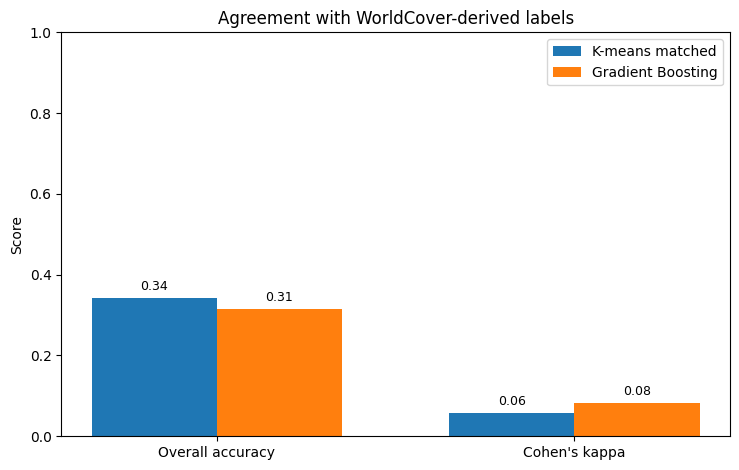

Corrected accuracy comparison runtime: 3.67 seconds
Saved accuracy figure to: /content/drive/MyDrive/GEOL0069_Data/figures/model_accuracy_comparison_cardiff.png


In [21]:
# Results: Corrected accuracy comparison
# K-means optimal matching vs Gradient Boosting


import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
)

t0 = time.perf_counter()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Check required variables

required_vars = [
    "label_arr",
    "labelled_mask",
    "cluster_map",
    "gb_class_map",
    "CLASS_VALUES",
    "CLASS_NAMES",
    "FIGURE_DIR",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError("Missing required variables: " + ", ".join(missing))


# 2. Extract reference labels and model predictions
# y_ref:
#   WorldCover-derived five-class reference labels.
# y_cluster:
#   Raw K-means cluster IDs.
#   These are not land-cover classes yet.
# y_gb:
#   Gradient Boosting land-cover class predictions.

y_ref_all = label_arr[labelled_mask].astype("uint8")
y_cluster_all = cluster_map[labelled_mask].astype("int16")
y_gb_all = gb_class_map[labelled_mask].astype("uint8")

valid_eval = (
    np.isin(y_ref_all, CLASS_VALUES) &
    (y_cluster_all >= 0) &
    np.isin(y_gb_all, CLASS_VALUES)
)

y_ref = y_ref_all[valid_eval]
y_cluster = y_cluster_all[valid_eval]
y_gb = y_gb_all[valid_eval]

print("Accuracy comparison")
print("=" * 60)
print(f"Evaluation pixels: {len(y_ref):,}")


# 3. Build K-means cluster-vs-reference confusion table

cluster_ids = np.sort(np.unique(y_cluster))
class_ids = np.array(CLASS_VALUES)

cluster_ref_matrix = np.zeros(
    (len(cluster_ids), len(class_ids)),
    dtype=int
)

for i, cluster_id in enumerate(cluster_ids):
    for j, class_id in enumerate(class_ids):
        cluster_ref_matrix[i, j] = np.sum(
            (y_cluster == cluster_id) & (y_ref == class_id)
        )

cluster_ref_df = pd.DataFrame(
    cluster_ref_matrix,
    index=[f"Cluster {c}" for c in cluster_ids],
    columns=[CLASS_NAMES[int(c)] for c in class_ids],
)

print("\nRaw K-means cluster versus WorldCover reference table")
display(cluster_ref_df)



# 4. Optimal K-means cluster-to-class matching
# Hungarian matching finds the class assignment that maximises agreement
# between K-means clusters and WorldCover-derived labels.

row_ind, col_ind = linear_sum_assignment(-cluster_ref_matrix)

kmeans_cluster_to_class = {
    int(cluster_ids[r]): int(class_ids[c])
    for r, c in zip(row_ind, col_ind)
}

print("\nOptimal K-means cluster-to-class mapping")
for cluster_id, class_id in sorted(kmeans_cluster_to_class.items()):
    print(f"Cluster {cluster_id} -> {CLASS_NAMES[class_id]}")


# 5. Convert K-means clusters to matched land-cover classes

y_kmeans_matched = np.array(
    [
        kmeans_cluster_to_class.get(int(cluster_id), 0)
        for cluster_id in y_cluster
    ],
    dtype="uint8"
)

# Also create a full matched K-means class map for later use
kmeans_matched_class_map = np.zeros(cluster_map.shape, dtype="uint8")

for cluster_id, class_id in kmeans_cluster_to_class.items():
    kmeans_matched_class_map[cluster_map == cluster_id] = class_id

print("\nUnique values in matched K-means class map:")
print(np.unique(kmeans_matched_class_map))


# 6. Calculate model accuracy metrics

model_accuracy_df = pd.DataFrame([
    {
        "model": "K-means matched",
        "overall_accuracy": accuracy_score(y_ref, y_kmeans_matched),
        "cohen_kappa": cohen_kappa_score(y_ref, y_kmeans_matched),
        "evaluation_pixels": len(y_ref),
    },
    {
        "model": "Gradient Boosting",
        "overall_accuracy": accuracy_score(y_ref, y_gb),
        "cohen_kappa": cohen_kappa_score(y_ref, y_gb),
        "evaluation_pixels": len(y_ref),
    },
])

print("\nModel agreement with WorldCover-derived labels")
display(model_accuracy_df.round(3))


# 7. Per-class reports

kmeans_matched_report_df = pd.DataFrame(
    classification_report(
        y_ref,
        y_kmeans_matched,
        labels=CLASS_VALUES,
        target_names=[CLASS_NAMES[i] for i in CLASS_VALUES],
        output_dict=True,
        zero_division=0,
    )
).T

gb_report_all_df = pd.DataFrame(
    classification_report(
        y_ref,
        y_gb,
        labels=CLASS_VALUES,
        target_names=[CLASS_NAMES[i] for i in CLASS_VALUES],
        output_dict=True,
        zero_division=0,
    )
).T

print("\nK-means matched classification report")
display(kmeans_matched_report_df.round(3))

print("\nGradient Boosting classification report")
display(gb_report_all_df.round(3))




# 8. Plot overall accuracy and Cohen's kappa

fig, ax = plt.subplots(figsize=(7.5, 4.8))

x = np.arange(2)
width = 0.35

kmeans_scores = model_accuracy_df.loc[
    model_accuracy_df["model"] == "K-means matched",
    ["overall_accuracy", "cohen_kappa"]
].values.flatten()

gb_scores = model_accuracy_df.loc[
    model_accuracy_df["model"] == "Gradient Boosting",
    ["overall_accuracy", "cohen_kappa"]
].values.flatten()

ax.bar(x - width / 2, kmeans_scores, width, label="K-means matched")
ax.bar(x + width / 2, gb_scores, width, label="Gradient Boosting")

ax.set_xticks(x)
ax.set_xticklabels(["Overall accuracy", "Cohen's kappa"])
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Agreement with WorldCover-derived labels")
ax.legend()

for i, value in enumerate(kmeans_scores):
    ax.text(
        i - width / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontsize=9,
    )

for i, value in enumerate(gb_scores):
    ax.text(
        i + width / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()

accuracy_path = FIGURE_DIR / "model_accuracy_comparison_cardiff.png"
fig.savefig(accuracy_path, dpi=300, bbox_inches="tight")
plt.show()



# 11. Runtime


if "timing" not in globals():
    timing = {}

timing["accuracy_comparison_corrected"] = time.perf_counter() - t0

print("=" * 60)
print(f"Corrected accuracy comparison runtime: {timing['accuracy_comparison_corrected']:.2f} seconds")
print(f"Saved accuracy figure to: {accuracy_path}")

## Mapped class-area comparison

The second comparison examines how much of the Cardiff study area each method assigns to each land-cover class. This is important because two models can have similar visual patterns but still estimate very different proportions of urban land, vegetation, water, or open/bare surfaces.

Class-area comparison is especially useful for assessing whether one method over-predicts a particular class. For example, an unrealistically high Water area would indicate confusion between water, shadow, and dark vegetation, while an unusually high Grass and crop area may indicate difficulty separating low vegetation from urban green space or open land.


Mapped class-area comparison


,model,class_id,class_name,pixel_count,pixel_percent,area_km2
0,K-means,1,Urban,22705,3.963,9.082
1,K-means,2,Tree and shrub,157209,27.439,62.884
2,K-means,3,Water,13962,2.437,5.585
3,K-means,4,Open land / Bare,213881,37.330,85.552
4,K-means,5,Grass and crop,165184,28.831,66.074
5,Gradient Boosting,1,Urban,165644,28.911,66.258
6,Gradient Boosting,2,Tree and shrub,129889,22.671,51.956
7,Gradient Boosting,3,Water,23,0.004,0.009
8,Gradient Boosting,4,Open land / Bare,142524,24.876,57.010
9,Gradient Boosting,5,Grass and crop,134861,23.538,53.944



Percentage-point difference: Gradient Boosting minus K-means


model,class_id,class_name,Gradient Boosting,K-means,difference_gb_minus_kmeans
0,1,Urban,28.911,3.963,24.948
1,2,Tree and shrub,22.671,27.439,-4.768
2,3,Water,0.004,2.437,-2.433
3,4,Open land / Bare,24.876,37.330,-12.455
4,5,Grass and crop,23.538,28.831,-5.293


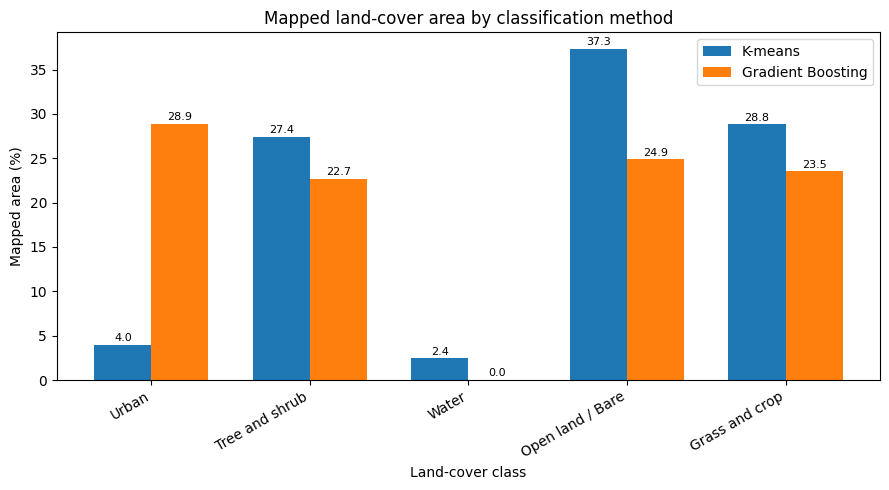

Class-area comparison runtime: 1.76 seconds
Saved figure to: /content/drive/MyDrive/GEOL0069_Data/figures/class_area_comparison_cardiff.png


In [22]:
# Results 2: Class-area comparison

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t0 = time.perf_counter()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Check required variables

required_vars = [
    "kmeans_class_map",
    "gb_class_map",
    "CLASS_VALUES",
    "CLASS_NAMES",
    "SCALE",
    "FIGURE_DIR",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError("Missing required variables: " + ", ".join(missing))


# 2. Area table helper

def make_area_table(class_map, model_name):
    valid_classes = class_map[np.isin(class_map, CLASS_VALUES)]
    class_ids, counts = np.unique(valid_classes, return_counts=True)

    area_df = pd.DataFrame({
        "model": model_name,
        "class_id": class_ids,
        "class_name": [CLASS_NAMES[int(i)] for i in class_ids],
        "pixel_count": counts,
    })

    area_df["pixel_percent"] = (
        100 * area_df["pixel_count"] / area_df["pixel_count"].sum()
    )

    area_df["area_km2"] = (
        area_df["pixel_count"] * (SCALE * SCALE) / 1_000_000
    )

    return area_df


kmeans_area_df = make_area_table(kmeans_class_map, "K-means")
gb_area_df = make_area_table(gb_class_map, "Gradient Boosting")

area_comparison_df = pd.concat(
    [kmeans_area_df, gb_area_df],
    ignore_index=True
)

print("Mapped class-area comparison")
display(area_comparison_df.round(3))


# 3. Prepare wide-format table for difference calculation

area_wide = area_comparison_df.pivot(
    index=["class_id", "class_name"],
    columns="model",
    values="pixel_percent"
).reset_index()

area_wide["difference_gb_minus_kmeans"] = (
    area_wide["Gradient Boosting"] - area_wide["K-means"]
)

print("\nPercentage-point difference: Gradient Boosting minus K-means")
display(area_wide.round(3))


# 4. Plot grouped class-area chart

plot_df = area_comparison_df.copy()
plot_df["class_id"] = plot_df["class_id"].astype(int)
plot_df = plot_df.sort_values(["class_id", "model"])

x = np.arange(len(CLASS_VALUES))
width = 0.36

kmeans_values = area_wide["K-means"].values
gb_values = area_wide["Gradient Boosting"].values
class_labels = area_wide["class_name"].values

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width / 2,
    kmeans_values,
    width,
    label="K-means",
)

ax.bar(
    x + width / 2,
    gb_values,
    width,
    label="Gradient Boosting",
)

ax.set_title("Mapped land-cover area by classification method")
ax.set_xlabel("Land-cover class")
ax.set_ylabel("Mapped area (%)")
ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=30, ha="right")
ax.legend()

for i, value in enumerate(kmeans_values):
    ax.text(i - width / 2, value + 0.4, f"{value:.1f}", ha="center", fontsize=8)

for i, value in enumerate(gb_values):
    ax.text(i + width / 2, value + 0.4, f"{value:.1f}", ha="center", fontsize=8)

plt.tight_layout()

area_path = FIGURE_DIR / "class_area_comparison_cardiff.png"
fig.savefig(area_path, dpi=300, bbox_inches="tight")
plt.show()


# 5. Runtime

if "timing" not in globals():
    timing = {}

timing["results_class_area_comparison"] = time.perf_counter() - t0

print("=" * 60)
print(f"Class-area comparison runtime: {timing['results_class_area_comparison']:.2f} seconds")
print(f"Saved figure to: {area_path}")

## Spatial agreement and disagreement between models

The third comparison identifies where K-means and Gradient Boosting assign the same class and where they disagree. This is useful because the research question is not only about overall accuracy, but also about which land-cover types are spectrally easy or difficult to separate.

Areas of agreement suggest that Sentinel-2 spectral bands and indices provide a clear signal for that class. Areas of disagreement indicate more uncertain land-cover boundaries, mixed pixels, or classes with similar spectral behaviour. In Cardiff, disagreement is expected around residential areas with gardens and trees, river edges, urban parks, cropland boundaries, and open/bare surfaces.


Model spatial agreement summary


,category,pixel_count,pixel_percent
0,Agreement,111019,19.377
1,Disagreement,461922,80.623



Class-specific agreement between K-means and Gradient Boosting


,class_id,class_name,shared_agreement_pixels,pixels_in_either_model,class_agreement_percent
0,1,Urban,3860,184489,2.092
1,2,Tree and shrub,14601,272497,5.358
2,3,Water,0,13985,0.000
3,4,Open land / Bare,54337,302068,17.988
4,5,Grass and crop,38221,261824,14.598


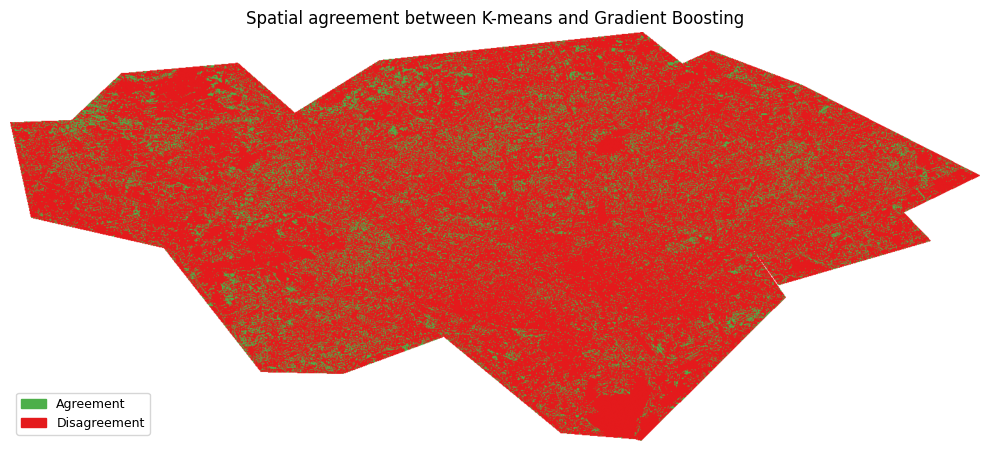

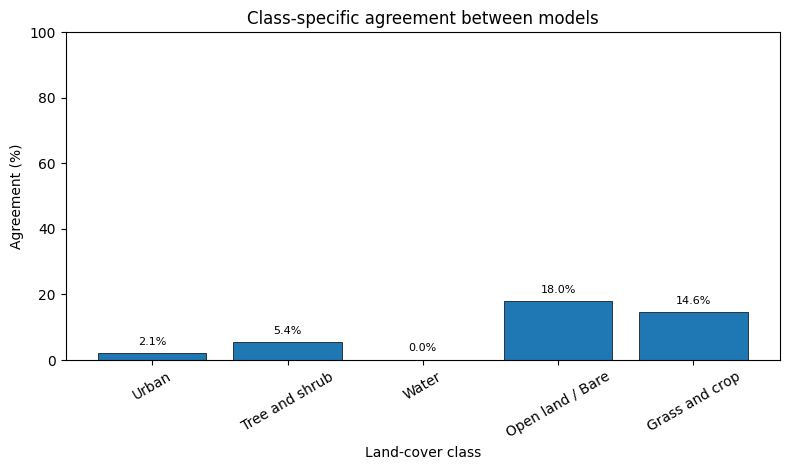

Spatial agreement runtime: 3.91 seconds
Saved agreement map to: /content/drive/MyDrive/GEOL0069_Data/figures/model_spatial_agreement_cardiff.png
Saved class agreement chart to: /content/drive/MyDrive/GEOL0069_Data/figures/class_specific_agreement_cardiff.png


In [23]:
# Results 3: Spatial agreement and disagreement between models

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

t0 = time.perf_counter()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Check required variables

required_vars = [
    "kmeans_class_map",
    "gb_class_map",
    "CLASS_VALUES",
    "CLASS_NAMES",
    "FIGURE_DIR",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError("Missing required variables: " + ", ".join(missing))


# 2. Create agreement and disagreement maps

valid_comparison = (
    np.isin(kmeans_class_map, CLASS_VALUES) &
    np.isin(gb_class_map, CLASS_VALUES)
)

agreement_map = np.zeros(kmeans_class_map.shape, dtype="uint8")
agreement_map[valid_comparison & (kmeans_class_map == gb_class_map)] = 1
agreement_map[valid_comparison & (kmeans_class_map != gb_class_map)] = 2

agreement_pixels = np.sum(agreement_map == 1)
disagreement_pixels = np.sum(agreement_map == 2)
total_pixels = agreement_pixels + disagreement_pixels

agreement_percent = 100 * agreement_pixels / total_pixels
disagreement_percent = 100 * disagreement_pixels / total_pixels

agreement_summary = pd.DataFrame([
    {
        "category": "Agreement",
        "pixel_count": agreement_pixels,
        "pixel_percent": agreement_percent,
    },
    {
        "category": "Disagreement",
        "pixel_count": disagreement_pixels,
        "pixel_percent": disagreement_percent,
    },
])

print("Model spatial agreement summary")
display(agreement_summary.round(3))


# 3. Class-specific agreement

class_agreement_rows = []

for class_id in CLASS_VALUES:
    class_mask = valid_comparison & (
        (kmeans_class_map == class_id) | (gb_class_map == class_id)
    )

    same_class = valid_comparison & (
        (kmeans_class_map == class_id) &
        (gb_class_map == class_id)
    )

    total_class_related = class_mask.sum()
    same_class_count = same_class.sum()

    class_agreement_rows.append({
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id],
        "shared_agreement_pixels": same_class_count,
        "pixels_in_either_model": total_class_related,
        "class_agreement_percent": (
            100 * same_class_count / total_class_related
            if total_class_related > 0 else np.nan
        ),
    })

class_agreement_df = pd.DataFrame(class_agreement_rows)

print("\nClass-specific agreement between K-means and Gradient Boosting")
display(class_agreement_df.round(3))


# 4. Plot agreement/disagreement map

agreement_colors = {
    0: "#ffffff",
    1: "#4daf4a",
    2: "#e41a1c",
}

agreement_cmap = ListedColormap([agreement_colors[i] for i in range(3)])
agreement_norm = BoundaryNorm(np.arange(-0.5, 3.5, 1), agreement_cmap.N)

legend_items = [
    mpatches.Patch(color=agreement_colors[1], label="Agreement"),
    mpatches.Patch(color=agreement_colors[2], label="Disagreement"),
]

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(
    agreement_map,
    cmap=agreement_cmap,
    norm=agreement_norm,
    origin="upper",
)

ax.set_title("Spatial agreement between K-means and Gradient Boosting")
ax.set_axis_off()
ax.legend(handles=legend_items, loc="lower left", frameon=True, fontsize=9)

plt.tight_layout()

agreement_path = FIGURE_DIR / "model_spatial_agreement_cardiff.png"
fig.savefig(agreement_path, dpi=300, bbox_inches="tight")
plt.show()


# 5. Plot class-specific agreement chart

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    class_agreement_df["class_name"],
    class_agreement_df["class_agreement_percent"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title("Class-specific agreement between models")
ax.set_xlabel("Land-cover class")
ax.set_ylabel("Agreement (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=30)

for _, row in class_agreement_df.iterrows():
    ax.text(
        row["class_name"],
        row["class_agreement_percent"] + 2,
        f"{row['class_agreement_percent']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()

class_agreement_path = FIGURE_DIR / "class_specific_agreement_cardiff.png"
fig.savefig(class_agreement_path, dpi=300, bbox_inches="tight")
plt.show()


## 6. Runtime

if "timing" not in globals():
    timing = {}

timing["results_spatial_agreement"] = time.perf_counter() - t0

print("=" * 60)
print(f"Spatial agreement runtime: {timing['results_spatial_agreement']:.2f} seconds")
print(f"Saved agreement map to: {agreement_path}")
print(f"Saved class agreement chart to: {class_agreement_path}")

# Discussion and Limitations

## What the results show about Sentinel-2 separability in Cardiff

The results show that Sentinel-2 spectral bands, NDVI, and NDBI can separate some broad land-cover patterns in Cardiff, but they do not fully distinguish the five target classes with high reliability. Both K-means and Gradient Boosting produced meaningful spatial patterns, but the accuracy comparison shows limited agreement with the WorldCover-derived labels. The matched K-means result achieved an overall accuracy of approximately 0.34, while Gradient Boosting achieved approximately 0.31. Cohen’s kappa was low for both methods, suggesting that much of the agreement with the reference layer is weak after accounting for chance agreement.

Sentinel-2 features are useful for identifying broad contrasts between vegetation, built-up areas, water, and open surfaces, but the five-class scheme is difficult to separate consistently in a complex urban environment such as Cardiff.

## Value of K-means clustering

K-means is useful because it shows the natural spectral structure of the Sentinel-2 feature space without using reference labels. In this project, K-means identified clusters with clear spectral differences. For example, the water cluster had low reflectance and negative NDVI, while the tree and shrub and grass/crop clusters had much higher NDVI values. This indicates that Sentinel-2 contains useful information for separating water and vegetation types.

However, K-means is limited because its clusters are not automatically land-cover classes. The cluster-to-class interpretation required post-hoc judgement using NDVI, NDBI, SWIR response, visible brightness, and map inspection. The original K-means accuracy was misleading because cluster labels are arbitrary. Therefore, the corrected evaluation used optimal cluster-to-class matching before calculating accuracy. Even after matching, the accuracy remained moderate, showing that unsupervised spectral clusters only partly correspond to the five WorldCover-derived land-cover classes.

## Performance of Gradient Boosting

Gradient Boosting was expected to perform better than K-means because it is a method trained using WorldCover-derived labels. However, in this project it did not clearly outperform K-means. Its overall accuracy was slightly lower than the matched K-means result, although its Cohen’s kappa was slightly higher. This suggests that the supervised model learned some label structure, but it also inherited noise and uncertainty from the reference labels.

The confusion matrix shows that Gradient Boosting struggled to separate several classes. Water was the most distinct class in the test set, but Urban, Tree and shrub, Open land / Bare, and Grass and crop were frequently confused. This is consistent with the Cardiff landscape, where residential areas often contain buildings, gardens, trees, roads, and shadows within the same 20 m pixel. The model therefore had difficulty assigning mixed pixels to a single class.

## Class-area differences between the two methods

The class-area comparison shows substantial differences between K-means and Gradient Boosting. K-means mapped a much smaller Urban area than Gradient Boosting, while Gradient Boosting mapped almost no Water after the water correction. K-means also mapped a larger proportion of Open land / Bare than Gradient Boosting. These differences indicate that the two methods interpret Cardiff’s spectral landscape in very different ways.

The disagreement is particularly important because both models used the same Sentinel-2 feature stack. Therefore, the differences are caused mainly by the modelling approach and class interpretation rather than by different input data. K-means follows spectral similarity, while Gradient Boosting follows the WorldCover-derived training labels. The strong disagreement map shows that the two methods do not converge on a stable five-class interpretation across much of Cardiff.

## Why urban and open surfaces are difficult to classify

The most ambiguous classes are Urban, Open land / Bare, and Grass and crop. These classes can overlap spectrally in Sentinel-2 imagery. Bright roofs, concrete, bare soil, dry grass, construction areas, and sparsely vegetated land can all produce similar reflectance in the visible and SWIR bands. At 20 m resolution, one pixel may contain a mixture of roofs, roads, gardens, trees, and shadows, making it difficult to assign a single land-cover class.

This issue is especially important in Cardiff because the study area includes dense urban areas, suburban housing, parks, river corridors, industrial land, docks, and rural margins. These land-cover types are spatially mixed and often occur at scales smaller than a Sentinel-2 pixel. As a result, the classification problem is not only a machine-learning problem, but also a spatial-resolution and mixed-pixel problem.

## Limitations of WorldCover-derived labels

A major limitation is that ESA WorldCover was used as the reference label source. WorldCover is useful because it provides consistent global land-cover information, but it is not perfect ground truth. It may contain errors in mixed urban areas, narrow rivers, small parks, wetlands, construction sites, and land-cover transition zones. If the reference label is wrong or too general, the supervised model may learn incorrect class relationships.

This also affects the reported accuracy. The accuracy values measure agreement with the remapped WorldCover layer, not true field-validated accuracy. Therefore, low accuracy does not necessarily mean that the models are entirely wrong; it may also reflect mismatch between Sentinel-2 pixels, WorldCover class definitions, and the actual land cover on the ground.

## Limitations of the five-class scheme

The five-class scheme is useful for comparing broad land-cover groups, but it simplifies Cardiff’s real landscape. For example, the Grass and crop class combines urban grass, agricultural fields, parks, sports fields, and herbaceous wetlands. These surfaces may have different spectral behaviour, but they are treated as one class. Similarly, Open land / Bare combines bare soil, sparse vegetation, and bright non-vegetated surfaces, which can overlap with both Urban and Grass and crop.

The Tree and shrub class also combines different vegetation structures. Dense woodland, individual trees, hedgerows, and shrubland may not behave identically in Sentinel-2 imagery. This class simplification helps make the project manageable, but it also reduces classification precision.

## Limitations of the modelling approach

K-means and Gradient Boosting answer different questions. K-means asks whether pixels naturally group into spectral clusters, while Gradient Boosting asks whether the input features can reproduce a labelled reference scheme. Because of this, the two methods should not be expected to produce identical maps.

Another limitation is that the Gradient Boosting model used only spectral bands and two indices. Additional features, such as texture, elevation, seasonal composites, Sentinel-1 radar backscatter, or multi-date vegetation metrics, could improve separation between urban, vegetation, and bare surfaces. The project also used a single growing-season composite, which may miss seasonal



# Environmental Cost Assessment

This section estimates the environmental cost of running the Cardiff land-cover classification workflow. The estimate is calculated from the measured runtime of each notebook stage stored in the `timing` dictionary. This makes the assessment specific to the actual Google Colab run used for this project.

The estimate includes the main computational stages of the workflow, including Google Earth Engine data preparation, K-means clustering, K-means interpretation, Gradient Boosting training and prediction, accuracy comparison, class-area comparison, and spatial agreement analysis where runtime values are available.

The calculation uses the following formulas:

`Energy (kWh) = runtime_hours × assumed_active_power_kW`

`CO2e (g) = energy_kWh × carbon_intensity_kgCO2e_per_kWh × 1000`

`Estimated electricity cost (£) = energy_kWh × electricity_price_gbp_per_kWh`

The following assumptions are used:

| Parameter             |     Assumed value |
| --------------------- | ----------------: |
| Active notebook power |          0.060 kW |
| Carbon intensity      | 0.125 kg CO2e/kWh |
| Electricity price     |       £0.2467/kWh |
| GPU use               |          Not used |

This is a simplified operational estimate rather than a full life-cycle assessment. It does not include the environmental cost of satellite construction, satellite launch, Google Earth Engine storage, data-centre construction, or background cloud infrastructure. It only estimates the energy, carbon emissions, and electricity cost associated with the measured active notebook computation.

The final total environmental cost is calculated in the code cell below by summing the measured runtimes of the completed project stages.




,Stage,Runtime (s),Runtime (min),Runtime (h),Energy (kWh),CO2e (g),Estimated cost (£)
0,Pre-processing from Google Earth Engine,10.69,0.178,0.00297,0.000178,0.0223,0.000044
1,K-means clustering,17.70,0.295,0.00492,0.000295,0.0369,0.000073
2,K-means interpretation,7.22,0.120,0.00200,0.000120,0.0150,0.000030
3,Gradient Boosting training and evaluation,3.11,0.052,0.00086,0.000052,0.0065,0.000013
4,Gradient Boosting prediction and mapping,49.93,0.832,0.01387,0.000832,0.1040,0.000205
5,Accuracy comparison,3.67,0.061,0.00102,0.000061,0.0076,0.000015
6,Class-area comparison,1.76,0.029,0.00049,0.000029,0.0037,0.000007
7,Spatial agreement analysis,3.91,0.065,0.00109,0.000065,0.0082,0.000016
8,Total measured workflow,97.99,1.633,0.02722,0.001633,0.2042,0.000403


Final environmental cost estimate
Total runtime: 97.99 seconds (1.633 minutes)
Total energy use: 0.001633 kWh
Total CO2e: 0.2042 g
Estimated electricity cost: £0.000403
Assumed active power: 0.060 kW
Carbon intensity: 0.125 kg CO2e/kWh
Electricity price: £0.2467/kWh
GPU used: No


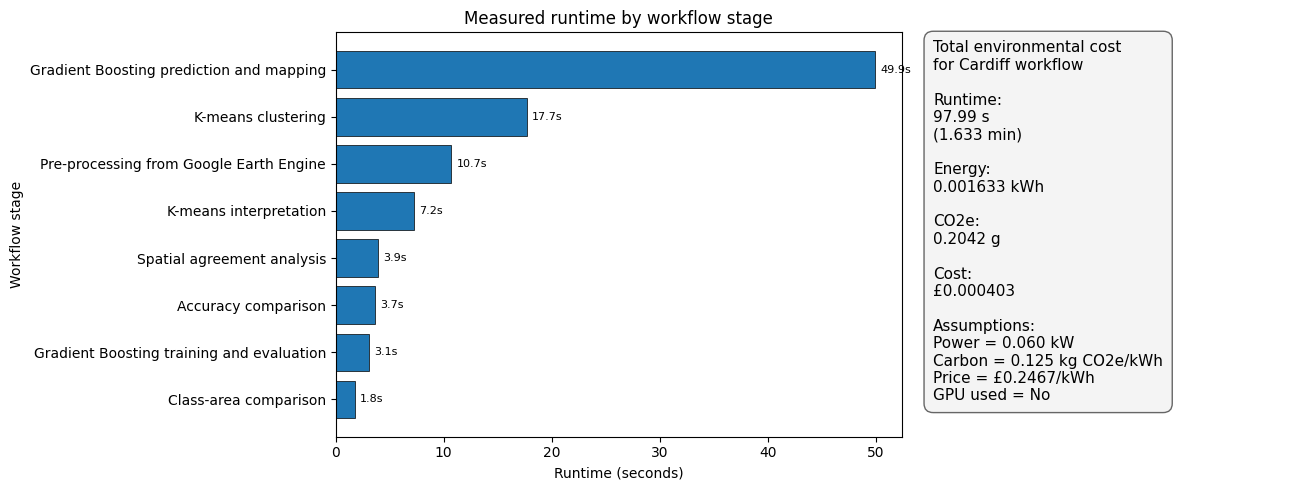

In [31]:
# Final environmental cost summary and diagram


import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t0 = time.perf_counter()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Assumptions

ASSUMED_ACTIVE_POWER_KW = 0.060
CARBON_INTENSITY_KGCO2E_PER_KWH = 0.125
ELECTRICITY_PRICE_GBP_PER_KWH = 0.2467
GPU_USED = "No"

# 2. Stages included in the final project

stage_definitions = [
    {
        "stage": "Pre-processing from Google Earth Engine",
        "key": "preprocessing",
    },
    {
        "stage": "K-means clustering",
        "key": "kmeans",
    },
    {
        "stage": "K-means interpretation",
        "key": "kmeans_interpretation",
    },
    {
        "stage": "Gradient Boosting training and evaluation",
        "key": "gradient_boosting_training_evaluation",
    },
    {
        "stage": "Gradient Boosting prediction and mapping",
        "key": "gradient_boosting_prediction_mapping",
    },
    {
        "stage": "Accuracy comparison",
        "key": "accuracy_comparison_corrected",
    },
    {
        "stage": "Class-area comparison",
        "key": "results_class_area_comparison",
    },
    {
        "stage": "Spatial agreement analysis",
        "key": "results_spatial_agreement",
    },
]

rows = []

for item in stage_definitions:
    key = item["key"]

    if key in timing and np.isfinite(timing[key]):
        runtime_seconds = timing[key]
        runtime_hours = runtime_seconds / 3600
        energy_kwh = runtime_hours * ASSUMED_ACTIVE_POWER_KW
        co2e_g = energy_kwh * CARBON_INTENSITY_KGCO2E_PER_KWH * 1000
        cost_gbp = energy_kwh * ELECTRICITY_PRICE_GBP_PER_KWH

        rows.append({
            "Stage": item["stage"],
            "Runtime (s)": runtime_seconds,
            "Runtime (min)": runtime_seconds / 60,
            "Runtime (h)": runtime_hours,
            "Energy (kWh)": energy_kwh,
            "CO2e (g)": co2e_g,
            "Estimated cost (£)": cost_gbp,
        })

environmental_cost_df = pd.DataFrame(rows)

if environmental_cost_df.empty:
    raise ValueError("No environmental cost stages found. Check the timing dictionary keys.")

# 3. Add total row

total = {
    "Stage": "Total measured workflow",
    "Runtime (s)": environmental_cost_df["Runtime (s)"].sum(),
    "Runtime (min)": environmental_cost_df["Runtime (min)"].sum(),
    "Runtime (h)": environmental_cost_df["Runtime (h)"].sum(),
    "Energy (kWh)": environmental_cost_df["Energy (kWh)"].sum(),
    "CO2e (g)": environmental_cost_df["CO2e (g)"].sum(),
    "Estimated cost (£)": environmental_cost_df["Estimated cost (£)"].sum(),
}

environmental_cost_summary_df = pd.concat(
    [environmental_cost_df, pd.DataFrame([total])],
    ignore_index=True
)

display(
    environmental_cost_summary_df.round({
        "Runtime (s)": 2,
        "Runtime (min)": 3,
        "Runtime (h)": 5,
        "Energy (kWh)": 6,
        "CO2e (g)": 4,
        "Estimated cost (£)": 6,
    })
)

# 4. Print final total values

print("Final environmental cost estimate")
print("=" * 60)
print(f"Total runtime: {total['Runtime (s)']:.2f} seconds ({total['Runtime (min)']:.3f} minutes)")
print(f"Total energy use: {total['Energy (kWh)']:.6f} kWh")
print(f"Total CO2e: {total['CO2e (g)']:.4f} g")
print(f"Estimated electricity cost: £{total['Estimated cost (£)']:.6f}")
print(f"Assumed active power: {ASSUMED_ACTIVE_POWER_KW:.3f} kW")
print(f"Carbon intensity: {CARBON_INTENSITY_KGCO2E_PER_KWH:.3f} kg CO2e/kWh")
print(f"Electricity price: £{ELECTRICITY_PRICE_GBP_PER_KWH:.4f}/kWh")
print(f"GPU used: {GPU_USED}")

# 5. Environmental cost diagram

plot_df = environmental_cost_df.sort_values("Runtime (s)", ascending=True)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    gridspec_kw={"width_ratios": [1.6, 1]}
)

# Runtime contribution by stage
axes[0].barh(
    plot_df["Stage"],
    plot_df["Runtime (s)"],
    edgecolor="black",
    linewidth=0.5
)

axes[0].set_title("Measured runtime by workflow stage")
axes[0].set_xlabel("Runtime (seconds)")
axes[0].set_ylabel("Workflow stage")

for i, value in enumerate(plot_df["Runtime (s)"]):
    axes[0].text(
        value + max(plot_df["Runtime (s)"]) * 0.01,
        i,
        f"{value:.1f}s",
        va="center",
        fontsize=8
    )

# Summary panel
axes[1].axis("off")

summary_text = (
    "Total environmental cost\n"
    "for Cardiff workflow\n\n"
    f"Runtime:\n{total['Runtime (s)']:.2f} s\n"
    f"({total['Runtime (min)']:.3f} min)\n\n"
    f"Energy:\n{total['Energy (kWh)']:.6f} kWh\n\n"
    f"CO2e:\n{total['CO2e (g)']:.4f} g\n\n"
    f"Cost:\n£{total['Estimated cost (£)']:.6f}\n\n"
    "Assumptions:\n"
    f"Power = {ASSUMED_ACTIVE_POWER_KW:.3f} kW\n"
    f"Carbon = {CARBON_INTENSITY_KGCO2E_PER_KWH:.3f} kg CO2e/kWh\n"
    f"Price = £{ELECTRICITY_PRICE_GBP_PER_KWH:.4f}/kWh\n"
    f"GPU used = {GPU_USED}"
)

axes[1].text(
    0.02,
    0.98,
    summary_text,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#f4f4f4",
        edgecolor="#666666",
        linewidth=1.0
    )
)

plt.tight_layout()

environmental_summary_path = FIGURE_DIR / "environmental_cost_summary_cardiff.png"
fig.savefig(environmental_summary_path, dpi=300, bbox_inches="tight")
plt.show()

## Environmental cost result

The measured runtime of the included Cardiff workflow stages was **97.99 seconds**, or approximately **1.63 minutes**. Using an assumed active notebook power of **0.060 kW**, this corresponds to an estimated energy use of **0.001633 kWh**. With a carbon intensity of **0.125 kg CO2e/kWh**, the workflow produced approximately **0.204 g CO2e**. The estimated electricity cost was approximately **£0.0004**.

This indicates that the direct computational footprint of the project is very low. The main reason is that the project uses moderate-resolution Sentinel-2 imagery, classical machine-learning methods, and no GPU-based deep learning. The largest runtime contribution came from the Gradient Boosting prediction and mapping stage, followed by K-means clustering and Google Earth Engine pre-processing.

This estimate only covers the measured notebook computation. It does not include upstream environmental costs such as Sentinel-2 satellite construction, launch, data storage, Google Earth Engine infrastructure, or repeated exploratory runs during development.

In [33]:
# Create requirements.txt for the Cardiff land-cover project


from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/GEOL0069_Data")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

requirements = """earthengine-api
geemap
geopandas
shapely
rasterio
numpy
pandas
matplotlib
scikit-learn
scipy
"""

requirements_path = PROJECT_DIR / "requirements.txt"

requirements_path.write_text(
    requirements,
    encoding="utf-8"
)

print(f"requirements.txt saved to: {requirements_path}")
print("\nFile contents:")
print(requirements_path.read_text(encoding="utf-8"))

requirements.txt saved to: /content/drive/MyDrive/GEOL0069_Data/requirements.txt

File contents:
earthengine-api
geemap
geopandas
shapely
rasterio
numpy
pandas
matplotlib
scikit-learn
scipy



# References


Chuvieco, E. (2016). *Fundamentals of satellite remote sensing: An environmental approach* (2nd ed.). CRC Press. https://doi.org/10.1201/b19478

GeeksforGeeks. (2025). *Gradient boosting in ML*. https://www.geeksforgeeks.org/machine-learning/ml-gradient-boosting/

GeeksforGeeks. (2026). *K means clustering – Introduction*. https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/

Google Earth Engine Data Catalog. (n.d.). *ESA WorldCover 10m v200*, `ESA/WorldCover/v200`. https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200

Google Earth Engine Data Catalog. (n.d.). *Harmonized Sentinel-2 MSI: MultiSpectral Instrument, Level-2A (SR)*, `COPERNICUS/S2_SR_HARMONIZED`. https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED

Google Earth Engine Data Catalog. (n.d.). *Sentinel-2: Cloud Probability*, `COPERNICUS/S2_CLOUD_PROBABILITY`. https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_CLOUD_PROBABILITY

Gorelick, N., Hancher, M., Dixon, M., Ilyushchenko, S., Thau, D., & Moore, R. (2017). Google Earth Engine: Planetary-scale geospatial analysis for everyone. *Remote Sensing of Environment, 202*, 18–27. https://doi.org/10.1016/j.rse.2017.06.031

Quick Map Tools. (n.d.). *Download administrative boundaries*. https://www.quickmaptools.com/download-boundaries

Rouse, J. W., Jr., Haas, R. H., Schell, J. A., & Deering, D. W. (1974). Monitoring vegetation systems in the Great Plains with ERTS. In *Proceedings of the Third Earth Resources Technology Satellite-1 Symposium* (NASA SP-351, Vol. 1, pp. 309–317). NASA. https://ui.adsabs.harvard.edu/abs/1974NASSP.351..309R/abstract

scikit-learn developers. (n.d.). *HistGradientBoostingClassifier*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html

scikit-learn developers. (n.d.). *KMeans*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

scikit-learn developers. (n.d.). *Silhouette score*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

